In [1]:
import nltk

In [26]:
## clean-grid-disruption-00-14-standardized-data

import pandas as pd
import numpy as np

data = pd.read_csv('../data/Grid_Disruption_00_14_standardized.csv')

# Drop Canada rows

data = data[~((data['Geographic Areas']!= np.nan) & (data['Geographic Areas'].str.contains('Canada')))]

data['Number of Customers Affected'].isnull().sum()
data['Number of Customers Affected'].value_counts()

#Convert 'Uknown' and like strings to Nan
data['Number of Customers Affected'] = data['Number of Customers Affected'].map(lambda x: x if (type(x) == float) else np.nan if (x.isalpha() ==True) else x)
# Convert '-' to Nan
data['Number of Customers Affected'] = data['Number of Customers Affected'].map(lambda x: x if (type(x) == float) else np.nan if (x=='-') else x)
data['Number of Customers Affected'].isnull().sum()

# Remove commas
data['Number of Customers Affected'] = data['Number of Customers Affected'].map(lambda x: x.replace(',','') if type(x) != float else x)

# Remove 'Approx. '
data['Number of Customers Affected'] = data['Number of Customers Affected'].map(lambda x: x.replace('Approx. ','')if type(x) != float else x)
data[(~data['Number of Customers Affected'].isnull())&data['Number of Customers Affected'].str.contains(' ')]

# Manually set specific rows
data.loc[1637,'Number of Customers Affected']= 2000000    # 2 million
data.loc[1191,'Number of Customers Affected']= 11175      # GRE (1900) Total 11175
data.loc[1262,'Number of Customers Affected']= 111000     # 111000 (peak)
data.loc[1290,'Number of Customers Affected']= np.nan     # Major Industrial Customer Load Reduction
data.loc[1299,'Number of Customers Affected']= 4          # Interruptible Tarriff 1-6 customers
data.loc[1301,'Number of Customers Affected']= 2500000    # 700000 (peak) 2500000 (actual)
data.loc[1323,'Number of Customers Affected']= 9000       # 8000 -10000
data.loc[1351,'Number of Customers Affected']= np.nan     # --
data.loc[1373,'Number of Customers Affected']= 1100000    # 1.1 million and 100000 gas customers
data.loc[1383,'Number of Customers Affected']= np.nan     # PG&E
data.loc[1412,'Number of Customers Affected']= np.nan     # PG&E
data.loc[1496,'Number of Customers Affected']= 250000     # Greater than 250000
data.loc[1498,'Number of Customers Affected']= 225353     # 94366 at peak total 225353
data.loc[1501,'Number of Customers Affected']= 62500      # 62500 at peak
data.loc[1505,'Number of Customers Affected']= 85000      # 85000 at peak
data.loc[1512,'Number of Customers Affected']= np.nan     # PG&E
data.loc[1529,'Number of Customers Affected']= 6          # 6 (utilities)
data.loc[1530,'Number of Customers Affected']= 200000     # 200000 (Peak)
data.loc[1532,'Number of Customers Affected']= 104195     # 104195 at 5:23 p.m. 11/13/03
data.loc[1540,'Number of Customers Affected']= 108000     # 108000 (Dist. And Trans. Combined)
data.loc[1541,'Number of Customers Affected']= 530000     # Over 530000 peak on 9/19/03
data.loc[1543,'Number of Customers Affected']= 50000      # Under 50000
data.loc[1545,'Number of Customers Affected']= 32000      # peak 32000 9/18/03 7:00 p.m.
data.loc[1547,'Number of Customers Affected']= 1800000    # 1.8 million
data.loc[1548,'Number of Customers Affected']= 4          # 4 (industrial)
data.loc[1550,'Number of Customers Affected']= 133000     # 93000 at peak 133000 cumulative
data.loc[1576,'Number of Customers Affected']= 115739     # 102842 (Georgia); 12897 (Alabama)
data.loc[1582,'Number of Customers Affected']= 340000     # over 340000
data.loc[1587,'Number of Customers Affected']= 1500000    # 1.5 million
data.loc[1595,'Number of Customers Affected']= 1          # 1 PG&E
data.loc[1599,'Number of Customers Affected']= 1          # 1 PG&E
data.loc[1600,'Number of Customers Affected']= 1          # 1 PG&E
data.loc[1609,'Number of Customers Affected']= 36073      # (residential) 36073
data.loc[1612,'Number of Customers Affected']= 127566     # 70848; 56718
data.loc[1615,'Number of Customers Affected']= 50000      # 25000 per hour
data.loc[1645,'Number of Customers Affected']= 425000     # 40000-45000

data['Number of Customers Affected'] =data['Number of Customers Affected'].map(lambda x: int(x)if type(x) != float else x)
data.to_csv('../data/Grid_Disruption_00_14_standardized_cleaned.csv', index=False)


## a_preprocessing.....Pull cities mentioned from text

import pandas as pd
import pickle
import re

cities = pickle.load(open( "../data/cities.p", "rb" ))
df = pd.read_csv('../data/combined_tweets_outages.csv')
df['city_pull']=''
count = 0
for row in range(df.shape[0]):                                # loop through rows of df
    row_lst = []                                              # create empty list for cities pulled
    text = re.findall('([\w]+)\s', df['text'][row])          # find all words
    added = re.findall('[@|#]([A-z]+)', df['text'][row])      # find all mentions and hashtags
    text.extend(added)                                        # list of words in 'text' string
    for word in text:                                         # loop through each word in 'text' string
        for state,city in cities.items():
            for t_city in city:
                for name in t_city:
                     if word == name:
                        row_lst.append(str(name+', '+state))
        if len(row_lst) !=0:
            df['city_pull'][row] = row_lst                    # add list to df if list has values
        else:
            df['city_pull'][row] = ''                         # else add empty string to df
    count +=1
    if count % 100 == 0:
        print(count)

df.to_csv('../data/combined_tweets_outages_cities.csv', index=False)

## b_preprocessing...Pull states mentioned in text and user names

import pandas as pd
import regex as re

df = pd.read_csv('../data/combined_tweets_outages_cities.csv' )
# Drop columns not used
df.drop(columns = ['likes','replies','retweets'],  axis = 1, inplace=True)
df['city_pull'] = df['city_pull'].map(lambda x: '' if type(x)!=str else x)
# Pull state abbreviation from text
state =['MA','ME','NY','RI','VT','CT','NH'] 

# Look for state abbreviations mentioned in text column
df['text_state_pull'] = df['text'].map(lambda x: re.findall(r'([A-Z]{2})',x)) 
df['text_state_pull'] = df['text_state_pull'].map(lambda lst: [st for st in lst if st in state])
df['text_state_pull'] = df['text_state_pull'].map(lambda x: '' if x==[] else x[0])
# Pull state abbreviation from username
# Look for state abbreviations located in user names
df['user_state_pull']=df['user'].map(lambda x: re.findall(r'([A-Z]{2})',x)) 

df['user_state_pull'] = df['user_state_pull'].map(lambda lst: [st for st in lst if st in state])
df['user_state_pull'] = df['user_state_pull'].map(lambda x: '' if x==[] else x[0])
df.to_csv('../data/combined_tweets_outages_cities_states.csv',index=False)

# 3_preprocessing 
import pandas as pd
tweets = pd.read_csv('../data/raw-data/monthlytweets.csv')
# initial cleaning
# Drop duplicates
tweets.drop_duplicates(inplace=True)
print(f"Total: {tweets.shape[0]}")
print(f"Unique: {tweets['id'].nunique()}")
sorted(tweets['timestamp'].unique(), reverse=True)[:3]
# # Get number of observations containing word
tweets[tweets['timestamp'].str.contains('http://bit.ly/yTIrUE\xa0', case=False, regex=True)]
# Drop row 7454
tweets.drop(tweets.index[7454], inplace=True)

# Drop rows where timestamp == timestamp
tweets = tweets[tweets['timestamp'] != 'timestamp']

#Drop rows where query is null
tweets = tweets[tweets['query'].isnull() != True]

# change to timeseries
# Set `timestamp` to datetime and set it to index
tweets['timestamp'] = pd.to_datetime(tweets['timestamp'])
tweets.set_index('timestamp', inplace=True)
tweets.head()
# Export as monthlytweets_cleaned.csv
tweets.to_csv('../data/monthlytweets_cleaned.csv', index=True)

## Tweet sources..
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import wordnet

tweets = pd.read_csv('./data/monthlytweets_cleaned.csv')
tweets.head()

## checking most frequently used words in the tweets

vect = CountVectorizer(stop_words='english', )
X = vect.fit_transform(tweets['text'])
text = pd.DataFrame(X.toarray(), columns=vect.get_feature_names())
text.index = tweets['timestamp']
text.head()

# include all the arabic words that are used in the dataset.
non_eng = text.columns[20385:].tolist()
non_eng

def common_data(list1, list2): 
    result = 0
  
    # traverse in the 1st list 
    for x in list1: 
  
        # traverse in the 2nd list 
        for y in list2: 
    
            # if one common 
            if x == y: 
                result = 1
                
    return(result) 

# create an empty list to store the indexes of the rows to exclude
to_exclude = []
counter = 0
# run through each row to decide what rows include any value from the non_eng list
for i in range(0,len(tweets)):
    # if there is any value from non_eng list, the if clause generates 1.
    if common_data(tweets.text[i].split(), non_eng) == 1:
        # if 1 is generated, then it is appended to the empty list.
        to_exclude.append(i)
    else:
        continue
tweets.drop(to_exclude, inplace=True)

# A count vectorizer is created under the name of vect and the stop words are removed
vect = CountVectorizer(stop_words='english', )

# All the tweet content is fitted into the vectorizer
X = vect.fit_transform(tweets['text'])

# All this series are attached to the dataframe called text
text = pd.DataFrame(X.toarray(), columns=vect.get_feature_names())

# index is changed to the timestamp
text.index = tweets['timestamp']
text.head()

%matplotlib inline
text.sum().sort_values(ascending = False).head(30).plot(kind = 'barh');

freq_all = pd.DataFrame(text.sum().sort_values(ascending = False).head(30), columns=['amount'])

freq_all['words'] = freq_all.index
freq_all.reset_index(inplace = True, drop = True)

"""The accoAfter taking a deeper look, I decided to take the following accounts out when I look for the most frequent words:

Andruzzi63
Breedon
joeandruzzifndn
lowfoot
HeartShare
smartwattinc
The reason of excluding them is that they are either accounts that have some sort of sponsorship deal or refer to one of the energy providers for advertisement purposes.
"""
user_exc = ['Andruzzi63', 'Breedon', 'joeandruzzifndn', 'lowfoot', 'HeartShare', 'smartwattinc']
tweets_exc = tweets.loc[~tweets['user'].isin(user_exc)]
X_exc = vect.fit_transform(tweets_exc['text'])
text_exc = pd.DataFrame(X_exc.toarray(), columns=vect.get_feature_names())
text_exc.index = tweets_exc['timestamp']
freq_exc = pd.DataFrame(text_exc.sum().sort_values(ascending = False).head(40), columns=['amount'])
freq_exc['words'] = freq_exc.index
freq_exc.reset_index(inplace = True, drop = True)

tweets.to_csv('./data/monthlytweets_cleaned_2.csv')

## Frequency Charts When an Outage Happened
tweets = pd.read_csv('./data/combined_tweets_outages.csv')
tweets = tweets[tweets['outage'] == 1]
vect = CountVectorizer(stop_words='english', )
X = vect.fit_transform(tweets['text'])
text = pd.DataFrame(X.toarray(), columns=vect.get_feature_names())
text.index = tweets['timestamp']
text.head()
%matplotlib inline
text.sum().sort_values(ascending = False).head(30).plot(kind = 'barh');
freq_all = pd.DataFrame(text.sum().sort_values(ascending = False).head(30), columns=['amount'])

freq_all['words'] = freq_all.index
freq_all.reset_index(inplace = True, drop = True)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.title('Most Frequent Words')
plt.barh(freq_all['words'], freq_all['amount'], align = 'center');

################################

import pandas as pd
import regex as re
# import data
df = pd.read_csv('../data/combined_tweets_outages_cities.csv' )
# Drop columns not used
df.drop(columns = ['likes','replies','retweets'],  axis = 1, inplace=True)
df['city_pull'] = df['city_pull'].map(lambda x: '' if type(x)!=str else x)
Pull state abbreviation from text
state =['MA','ME','NY','RI','VT','CT','NH'] 

# Look for state abbreviations mentioned in text column
df['text_state_pull'] = df['text'].map(lambda x: re.findall(r'([A-Z]{2})',x)) 
df['text_state_pull'] = df['text_state_pull'].map(lambda lst: [st for st in lst if st in state])
df['text_state_pull'] = df['text_state_pull'].map(lambda x: '' if x==[] else x[0])
Pull state abbreviation from username
# Look for state abbreviations located in user names
df['user_state_pull']=df['user'].map(lambda x: re.findall(r'([A-Z]{2})',x)) 

df['user_state_pull'] = df['user_state_pull'].map(lambda lst: [st for st in lst if st in state])
df['user_state_pull'] = df['user_state_pull'].map(lambda x: '' if x==[] else x[0])
df.to_csv('../data/combined_tweets_outages_cities_states.csv',index=False)

##################################-----------------------------------------######
import pandas as pd
Read in data
tweets = pd.read_csv('../data/raw-data/monthlytweets.csv')
Initial cleaning
# Drop duplicates
tweets.drop_duplicates(inplace=True)
print(f"Total: {tweets.shape[0]}")
print(f"Unique: {tweets['id'].nunique()}")
Total: 20163
Unique: 20163
sorted(tweets['timestamp'].unique(), reverse=True)[:3]
['timestamp', 'http://bit.ly/yTIrUE\xa0', '2012-12-31 22:22:25']
# # Get number of observations containing word
tweets[tweets['timestamp'].str.contains('http://bit.ly/yTIrUE\xa0', case=False, regex=True)]
# Drop row 7454
tweets.drop(tweets.index[7454], inplace=True)
# Drop rows where timestamp == timestamp
tweets = tweets[tweets['timestamp'] != 'timestamp']
#Drop rows where query is null
tweets = tweets[tweets['query'].isnull() != True]
tweets.isnull().sum()
# Set `timestamp` to datetime and set it to index
tweets['timestamp'] = pd.to_datetime(tweets['timestamp'])
tweets.set_index('timestamp', inplace=True)
tweets.head()
tweets.to_csv('../data/monthlytweets_cleaned.csv', index=True)

SyntaxError: invalid syntax (4082027578.py, line 273)

## Tweet Sources Analysis

In [ ]:
#### Tweet Sources analysis
# necessary libraries:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import wordnet
# uploading the data:
tweets = pd.read_csv('./data/monthlytweets_cleaned.csv')
tweets.head()
tweets['user'].value_counts().head(10)
# result is the following
# nationalgridus     6081
# EversourceNH       1991
# NGPowerofAction     381
# EversourceMA        198
# Andruzzi63          115
# national_grid       111
# Breedon             110
# joeandruzzifndn     106
# BillericaPD          80
# ToSaveEnergy         67
# Name: user, dtype: int64
vect = CountVectorizer(stop_words='english', )
X = vect.fit_transform(tweets['text'])
text = pd.DataFrame(X.toarray(), columns=vect.get_feature_names())
text.index = tweets['timestamp']
text.head()
# include all the arabic words that are used in the dataset.
non_eng = text.columns[20385:].tolist()
non_eng
def common_data(list1, list2): 
    result = 0
  
    # traverse in the 1st list 
    for x in list1: 
  
        # traverse in the 2nd list 
        for y in list2: 
    
            # if one common 
            if x == y: 
                result = 1
                
    return(result) 
# create an empty list to store the indexes of the rows to exclude
to_exclude = []
counter = 0
# run through each row to decide what rows include any value from the non_eng list
for i in range(0,len(tweets)):
    # if there is any value from non_eng list, the if clause generates 1.
    if common_data(tweets.text[i].split(), non_eng) == 1:
        # if 1 is generated, then it is appended to the empty list.
        to_exclude.append(i)
    else:
        continue
# A count vectorizer is created under the name of vect and the stop words are removed
vect = CountVectorizer(stop_words='english', )

# All the tweet content is fitted into the vectorizer
X = vect.fit_transform(tweets['text'])

# All this series are attached to the dataframe called text
text = pd.DataFrame(X.toarray(), columns=vect.get_feature_names())

# index is changed to the timestamp
text.index = tweets['timestamp']
text.head()
freq_all = pd.DataFrame(text.sum().sort_values(ascending = False).head(30), columns=['amount'])
freq_all['words'] = freq_all.index
freq_all.reset_index(inplace = True, drop = True)
tweets['user'].value_counts().head(30)
# nationalgridus     6081
# EversourceNH       1991
# NGPowerofAction     381
# EversourceMA        198
# Andruzzi63          115
# national_grid       111
# Breedon             110
# joeandruzzifndn     106
# BillericaPD          80
# ToSaveEnergy         67
# Jackie500            62
# CodyHopkins          60
# lowfoot              55
# sprinter4883         54
# srinisankar          45
# wallabywayyy         40
# TyngsboroughMA       38
# AndreaWBZ            37
# HeartShare           37
# Dedprez11            36
# noternie             35
# acraftymitch         35
# st0ut717             34
# divajla              34
# smartwattinc         34
# MelrosePatch         32
# mktobin              29
# mnrochelle           28
# HarderServices       27
# Chines               27
# Name: user, dtype: int64
X_exc = vect.fit_transform(tweets_exc['text'])
text_exc = pd.DataFrame(X_exc.toarray(), columns=vect.get_feature_names())
text_exc.index = tweets_exc['timestamp']
freq_exc = pd.DataFrame(text_exc.sum().sort_values(ascending = False).head(40), columns=['amount'])
freq_exc['words'] = freq_exc.index
freq_exc.reset_index(inplace = True, drop = True)
tweets.to_csv('./data/monthlytweets_cleaned_2.csv')
# Frequency Charts When an Outage Happened
tweets = pd.read_csv('./data/combined_tweets_outages.csv')
tweets = tweets[tweets['outage'] == 1]
vect = CountVectorizer(stop_words='english', )
X = vect.fit_transform(tweets['text'])
text = pd.DataFrame(X.toarray(), columns=vect.get_feature_names())
text.index = tweets['timestamp']
freq_all = pd.DataFrame(text.sum().sort_values(ascending = False).head(30), columns=['amount'])
freq_all['words'] = freq_all.index
freq_all.reset_index(inplace = True, drop = True)

In [27]:
cd C:\Users\mr00065\Downloads

C:\Users\mr00065\Downloads


C:\Users\mr00065\AppData\Local\Temp\ipykernel_3852\1544968761.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweets['to'][i] = np.nan
C:\Users\mr00065\AppData\Local\Temp\ipykernel_3852\1544968761.py:85: FutureWarning: The default value of regex will change from True to False in a future version.
  network['from'] = network['from'].str.replace(r'[^\w\s]+', '')
C:\Users\mr00065\AppData\Local\Temp\ipykernel_3852\1544968761.py:86: FutureWarning: The default value of regex will change from True to False in a future version.
  network['to'] = network['to'].str.replace(r'[^\w\s]+', '')


ImportError: cannot import name 'from_networkx' from 'bokeh.models.graphs' (C:\Users\mr00065\Anaconda3\envs\tensorflow\lib\site-packages\bokeh\models\graphs.py)

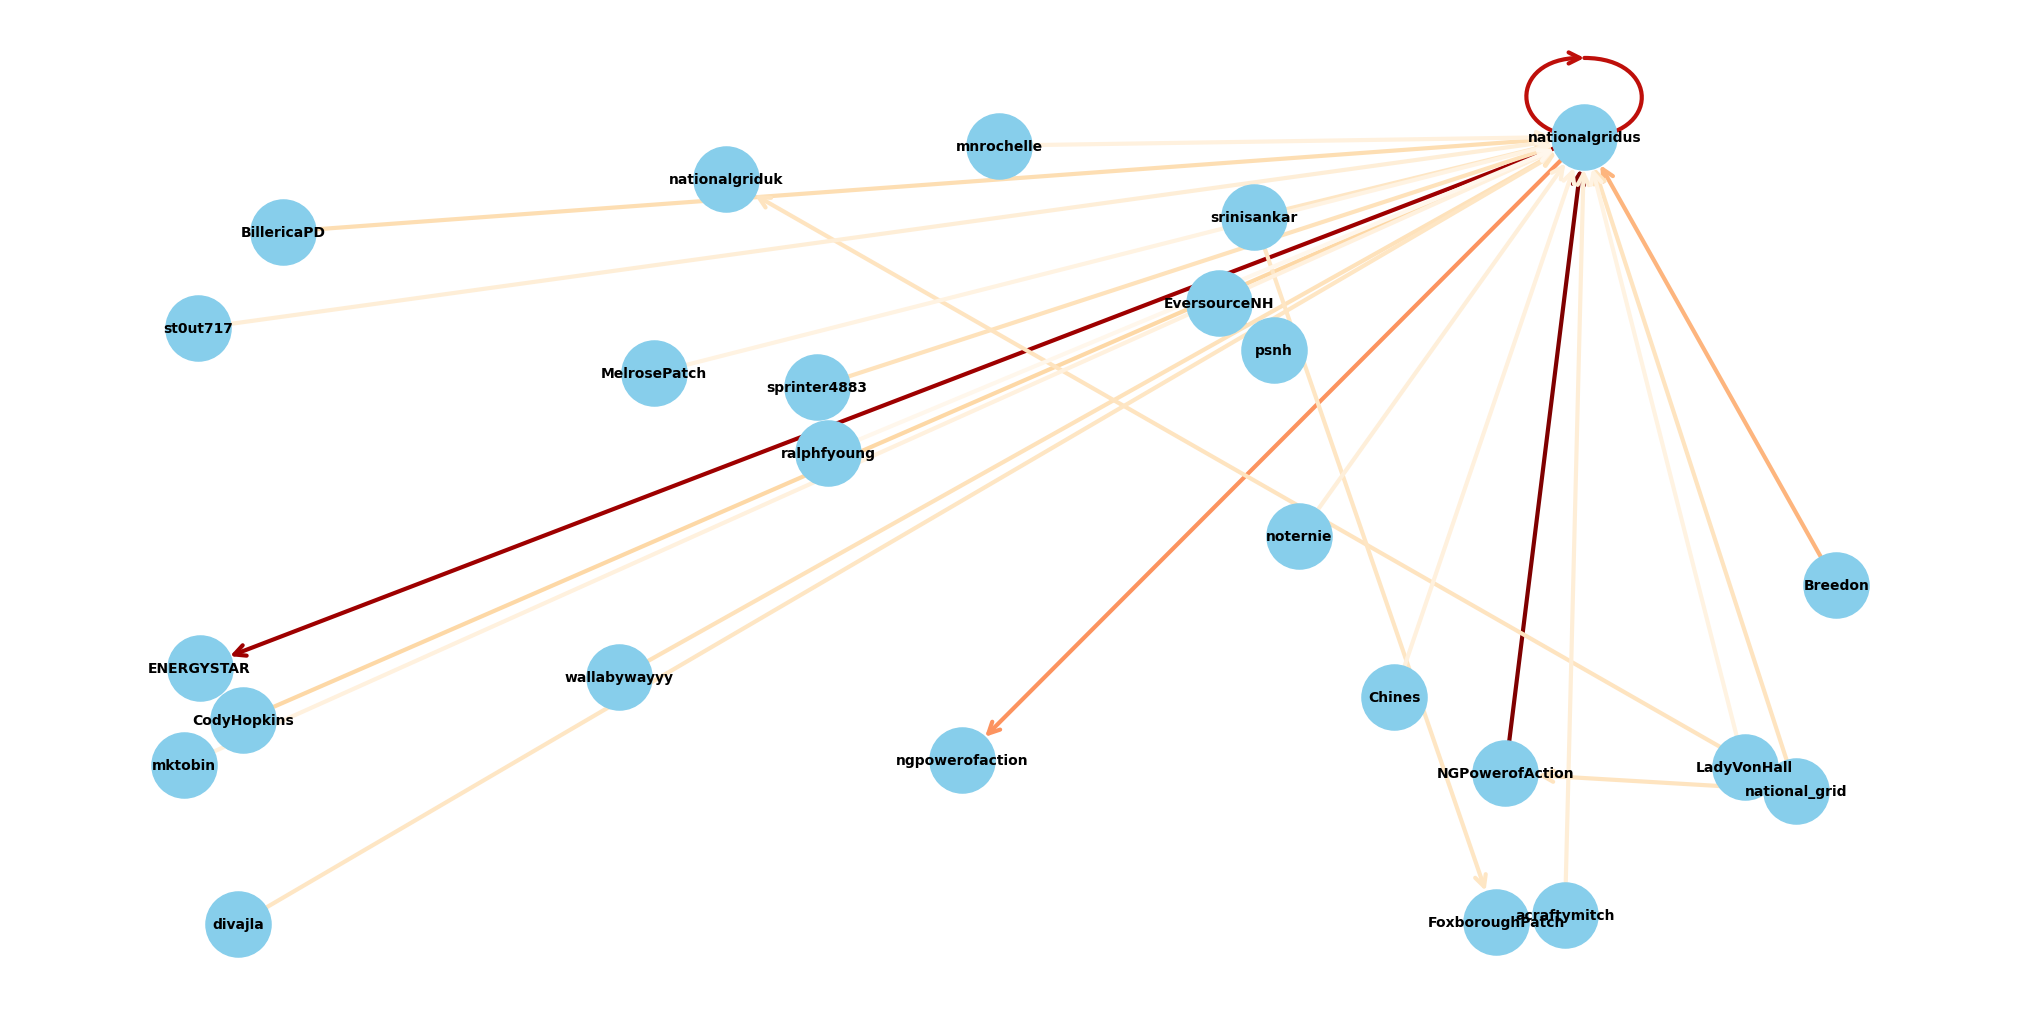

In [2]:
## Network Diagram of Twitter Users During Power Outages

# Necessary libraries
import pandas as pd
import regex as re
import string
import numpy as np
# Downloading the dataset:
tweets = pd.read_csv('combined_tweets_outages.csv')
# Changing the names of the columns to understand from which 
# account the tweet comes from and to where it goes.
tweets = tweets.rename(index=str, columns={'user':'from'})
# Creating an empty 'to' column to indicate the destinations of the nodes:
tweets['to'] = ''
# Reorganizing the columns according to the column names
tweets = tweets[['timestamp', 'id', 'text', 'from', 'to', 'outage' ,'likes', 'replies', 'retweets', 'query']]
# Since we will use the tweet post to understand the destination, I copied to that to
# 'to' column which will be replaced with the destination
tweets.to = tweets.text
# An empty list is created by appending all the posts to a single list
# at the end we have a big list of lists
tweets_lst = []
for i in range(0,len(tweets)):
    somelst=[]
    somelst.append(tweets['to'][i])
    tweets_lst.append(somelst)    


# Since in the Twitter, you need to use '@' to mention some other account,
# if we can grab all the string having that symbol, we can understand the destinations

import itertools

# An empty list is created to append the destionations
# This list is updated for each row and assigned to the 'to' column for that specific row.
mentions = []

for j in range(0, len(tweets_lst)):

    nested_list = tweets_lst[j:(j+1)] # nested list is the single tweet as a single list in a list
    flat_list = list(itertools.chain.from_iterable(nested_list)) # converting that list of list into a list of single text
    nested_words = [i.split(' ') for i in flat_list] # seperating all the words one by one in a 
                                                     # list and then saving them in a list
    words = list(itertools.chain.from_iterable(nested_words)) # converting them to a single list of words.
    
    # wish_lst is for words that start with '@'
    for i in range(0,len(words)): # iterate through all the words in the list
        # empty list is created
        wish_lst = [] 
        
        for word in words: # for each word
            if (len(word) > 0): # just to be safe, wanted to check the length
                if (word[0] == '@'): # if '@' is the first letter of the word
                    wish_lst.append(word[1:]) # if yes, append that to the wish_lst list
                else:
                    continue
    
    # at the end all of these words must be added to the mentions list. This will be placed in the mentions column.
    mentions.append(wish_lst)
# column is set to the list
tweets['to'] = mentions
# empty ones are replaced with np.nan
for i in range(0,len(tweets)):
    if tweets['to'][i] == []:
        tweets['to'][i] = np.nan
# drop na's because they are not creating any traffic
tweets_sub = tweets[['timestamp','id','from','to','outage']].dropna()

## Tweets Sent During an Outage
# filter out only the rows where outage is equal to 1.
# In other words, the rows that only happened during an outage
tweets_sub = tweets_sub[tweets_sub['outage'] == 1]

# A new data frame is created under the name of network. This data frame displays each 
# interaction between the nodes but there are duplicates.
network = tweets_sub.set_index('from').to.apply(pd.Series).stack().reset_index(level=0).rename(columns={0:'to'})

# If there is any empty cell, we replaced them with np.nan so that the na's can be dropped.
network['from'] = network['from'].map(lambda cell: np.nan if cell == '' else cell)
network['to'] = network['to'].map(lambda cell: np.nan if cell == '' else cell)

network.dropna(inplace = True)
# Another issue was the punctuations. For instance there are rows like 'nationalgrid:'
# This examples increase the number of nodes although it is an existing node which is referred.
network['from'] = network['from'].str.replace(r'[^\w\s]+', '')
network['to'] = network['to'].str.replace(r'[^\w\s]+', '')
network.reset_index(inplace = True, drop= True)

network['to'] = network['to'].map(lambda cell: np.nan if cell == '' else cell)
network.dropna(inplace = True)
# In order to visualize the dataframe easier, I ordered the columns alphabetically
network.sort_values(by = ['from'], inplace = True)
network.sort_values(by = ['to'], inplace = True)
# reset the index
network.reset_index(inplace=True, drop=True)
final_net = network.groupby(network.columns.tolist()).size().reset_index().rename(columns={0:'count'})
final_net = final_net.sort_values(by=('count'), ascending=False).reset_index(drop=True)
## Directed Graph
# Draw a graph with directed edges using a colormap and different node sizes.
# Edges have different colors and alphas (opacity). Drawn using matplotlib.
# libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
 
plt.figure(figsize=(20,10))
# Build your graph
G=nx.from_pandas_edgelist(final_net.head(25), 'from', 'to', create_using=nx.DiGraph() )

# Custom the nodes:
nx.draw(G, with_labels=True, 
        node_color='skyblue', node_size=2200, 
        edge_color=final_net.head(25)['count'], width=3, edge_cmap=plt.cm.OrRd,
        arrowstyle='->',arrowsize=20,
        font_size=10, font_weight="bold",
        pos=nx.random_layout(G, seed=13))
        #pos=nx.shell_layout(G),)

# Graph using Bokeh
import networkx as nx

from bokeh.io import show, output_file
from bokeh.models import Plot, Range1d, MultiLine, Circle, HoverTool, BoxZoomTool, ResetTool
from bokeh.models.graphs import from_networkx
from bokeh.palettes import Spectral4
# Prepare Data
G=nx.from_pandas_edgelist(final_net.head(25), 'from', 'to', create_using=nx.DiGraph() )
# to assign different colors to different bins, we created 5 bins.
# The darkest is for the most frequent edge and lighter means less traffic.
deg1, deg2, deg3, deg4, deg5 = '#8B4513', '#A0522D', '#CD853F', '#DEB887', '#FFE4B5'
edge_attrs = {}
for start_node, end_node, _ in G.edges(data=True):
    
    # created a mask for data frame. Essential to filter out the rows we need.
    mask = int(final_net[(final_net['from'] == start_node) & (final_net['to'] == end_node)]['count'])

    # Assigned corresponding colors to each one of the nodes
    if int(mask) > 50 :
        edge_color = deg1
    elif (int(mask) <= 50) & (int(mask) > 40):
        edge_color = deg2
    elif (int(mask) <= 40) & (int(mask) > 34):
        edge_color = deg3
    elif (int(mask) <= 34) & (int(mask) > 28):
        edge_color = deg4
    else: 
        edge_color = deg5
    
    edge_attrs[(start_node, end_node)] = edge_color # assign the colors to the nodes.
nx.set_edge_attributes(G, edge_attrs, "edge_color")

# Show with Bokeh
plot = Plot(plot_width=400, plot_height=400,
            x_range=Range1d(-1.1, 1.1), y_range=Range1d(-1.1, 1.1))
plot.title.text = "Graph Interaction Demonstration"

node_hover_tool = HoverTool(tooltips=[("Node", "@index")])
plot.add_tools(node_hover_tool, BoxZoomTool(), ResetTool())

# Listed all the necessary layout options that might match our visual preferences: 
# graph_renderer = from_networkx(G, nx.circular_layout, scale=1, center=(0, 0))
# graph_renderer = from_networkx(G, nx.random_layout, center = (-0.5,-0.5))
graph_renderer = from_networkx(G, nx.shell_layout,  center=(0, 0))
# graph_renderer = from_networkx(G, nx.spring_layout, scale=1, center=(0, 0))

graph_renderer.node_renderer.glyph = Circle(size=15, fill_color=Spectral4[0])
graph_renderer.edge_renderer.glyph = MultiLine(line_color="edge_color", line_alpha=0.8, line_width=2)
plot.renderers.append(graph_renderer)

output_file("interactive_graphs.html")
show(plot)

# Active Accounts Only During Outage
# filter out only the rows where outage is equal to 0.
# In other words, the rows that only happened during an outage
tweets_sub0 = tweets[['timestamp','id','from','to','outage']].dropna()
tweets_sub0 = tweets_sub0[tweets_sub0['outage'] == 0]

# A new data frame is created under the name of network. This data frame displays each 
# interaction between the nodes but there are duplicates.
network0 = tweets_sub0.set_index('from').to.apply(pd.Series).stack().reset_index(level=0).rename(columns={0:'to'})
# If there is any empty cell, we replaced them with np.nan so that the na's can be dropped.
network0['from'] = network0['from'].map(lambda cell: np.nan if cell == '' else cell)
network0['to'] = network0['to'].map(lambda cell: np.nan if cell == '' else cell)
network0.dropna(inplace = True)
# Another issue was the punctuations. For instance there are rows like 'nationalgrid:'
# This examples increase the number of nodes although it is an existing node which is referred.
network0['from'] = network0['from'].str.replace(r'[^\w\s]+', '')
network0['to'] = network0['to'].str.replace(r'[^\w\s]+', '')
network0.reset_index(inplace = True, drop= True)
network0['to'] = network0['to'].map(lambda cell: np.nan if cell == '' else cell)
network0.dropna(inplace = True)
# In order to visualize the dataframe easier, I ordered the columns alphabetically
network0.sort_values(by = ['from'], inplace = True)
network0.sort_values(by = ['to'], inplace = True)
# reset the index
network0.reset_index(inplace=True, drop=True)
final_net0 = network0.groupby(network0.columns.tolist()).size().reset_index().rename(columns={0:'count'})
final_net0 = final_net0.sort_values(by=('count'), ascending=False).reset_index(drop=True)
# Just for the sake of simplicity, I will only include the interactions that happened more than once in both
final_net = final_net[final_net['count'] > 5]
final_net0 = final_net0[final_net0['count'] > 5]
int_lst = []
for i in range(0,len(final_net0)):

    for j in range(0, len(final_net)):
        some_lst = []
        
        if final_net0['from'][i] == final_net['from'][j]:
            if final_net0['to'][i] == final_net['to'][j]:
                
                dif = int(final_net['count'][i]) - int(final_net0['count'][i])
                
                some_lst.append(final_net0['from'][i])
                some_lst.append(final_net0['to'][i])
                some_lst.append(dif)
                int_lst.append(some_lst)
            else:
                continue
        else:
            continue

first_to = []
second_from = []
third_cnt = []
for i in range(0,len(int_lst)):
    first_to.append(int_lst[i][0])
    second_from.append(int_lst[i][1])
    third_cnt.append(int_lst[i][2])
df = pd.DataFrame([])
df['from'] = pd.Series(first_to)
df['to'] = pd.Series(second_from)
df['count'] = pd.Series(third_cnt)
df = df.sort_values(by='count', ascending = False)
df.reset_index(inplace=True, drop=True)
df.head()

## Directed Graph
# libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
 
plt.figure(figsize=(20,10))
# Build your graph
G=nx.from_pandas_edgelist(df.head(25), 'from', 'to', create_using=nx.DiGraph() )

# Custom the nodes:
nx.draw(G, with_labels=True, 
        node_color='skyblue', node_size=2200, 
        edge_color=final_net.head(25)['count'], width=3, edge_cmap=plt.cm.OrRd,
        arrowstyle='->',arrowsize=20,
        font_size=10, font_weight="bold",
        pos=nx.random_layout(G, seed=13))
        #pos=nx.shell_layout(G),)

# Graph using Bokeh
import networkx as nx

from bokeh.io import show, output_file
from bokeh.models import Plot, Range1d, MultiLine, Circle, HoverTool, BoxZoomTool, ResetTool
from bokeh.models.graphs import from_networkx
from bokeh.palettes import Spectral4
# Prepare Data
G=nx.from_pandas_edgelist(df.head(25), 'from', 'to', create_using=nx.DiGraph() )

# to assign different colors to different bins, we created 4 bins.
# The darkest is for the most frequent edge and lighter means less traffic.
deg1, deg2, deg3, deg4 = '#8B4513', '#A0522D', '#CD853F', '#DEB887'
edge_attrs = {}

for start_node, end_node, _ in G.edges(data=True):
    
    # created a mask for data frame. Essential to filter out the rows we need.
    mask = int(final_net[(final_net['from'] == start_node) & (final_net['to'] == end_node)]['count'])

    # Assigned corresponding colors to each one of the nodes
    if int(mask) == 5 :
        edge_color = deg1
    elif (int(mask) == 4):
        edge_color = deg2
    elif (int(mask) == 3):
        edge_color = deg3
    else: 
        edge_color = deg4
    
    edge_attrs[(start_node, end_node)] = edge_color # assign the colors to the nodes.
nx.set_edge_attributes(G, edge_attrs, "edge_color")
# Show with Bokeh
plot = Plot(plot_width=400, plot_height=400,
            x_range=Range1d(-1.1, 1.1), y_range=Range1d(-1.1, 1.1))
plot.title.text = "Graph Interaction Demonstration"

node_hover_tool = HoverTool(tooltips=[("Node", "@index")])
plot.add_tools(node_hover_tool, BoxZoomTool(), ResetTool())

# Listed all the necessary layout options that might match our visual preferences: 
# graph_renderer = from_networkx(G, nx.circular_layout, scale=1, center=(0, 0))
# graph_renderer = from_networkx(G, nx.random_layout, center = (-0.5,-0.5))
graph_renderer = from_networkx(G, nx.shell_layout,  center=(0, 0))
# graph_renderer = from_networkx(G, nx.spring_layout, scale=1, center=(0, 0))

graph_renderer.node_renderer.glyph = Circle(size=15, fill_color=Spectral4[0])
graph_renderer.edge_renderer.glyph = MultiLine(line_color="edge_color", line_alpha=0.8, line_width=2)
plot.renderers.append(graph_renderer)

output_file("interactive_graphs.html")
show(plot)


In [5]:
## Power outages with state & time info
import pandas as pd
import numpy as np
from collections import OrderedDict
df = pd.read_csv('Grid_Disruption_00_14_standardized_cleaned.csv')
#Drop rows
#Drop rows with missing geographic data.

# # Look at unique Geographic Areas
# sorted(df['Geographic Areas'].astype(str).unique())
df = df[df['Geographic Areas'] != '-']
df = df[df['Geographic Areas'].notnull()]
us_state_abbrev = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY',
    'Puerto Rico': 'PR',
}

#Create State column
# Set up empty column
df['State'] = ''
#If Geographic Areas contains state name or abbreviation, include abbreviation in State column.

for state in us_state_abbrev:
    df.loc[df['Geographic Areas'].str.contains(state), 'State'] += f'{us_state_abbrev[state]} '
    df.loc[((df['Geographic Areas'].str.contains(us_state_abbrev[state])) & (us_state_abbrev[state] not in df['State'])), 'State'] += f'{us_state_abbrev[state]} '
df.loc[(df['Geographic Areas'].str.contains('Bakersfield') & ('CA ' not in df['State'])), 'State'] += f'CA '
df.loc[(df['Geographic Areas'].str.contains('Los Angeles') & ('CA ' not in df['State'])), 'State'] += f'CA '
df.loc[(df['Geographic Areas'].str.contains('Sacramento') & ('CA ' not in df['State'])), 'State'] += f'CA '
df.loc[(df['Geographic Areas'].str.contains('San Diego') & ('CA ' not in df['State'])), 'State'] += f'CA '
df.loc[(df['Geographic Areas'].str.contains('San Francisco') & ('CA ' not in df['State'])), 'State'] += f'CA '
df.loc[(df['Geographic Areas'].str.contains('Connecicut') & ('CT ' not in df['State'])), 'State'] += f'CT '
df.loc[(df['Geographic Areas'].str.contains('Maui') & ('HI ' not in df['State'])), 'State'] += f'HI '
df.loc[(df['Geographic Areas'].str.contains('Oahu') & ('HI ' not in df['State'])), 'State'] += f'HI '
df.loc[(df['Geographic Areas'].str.contains('Akron') & ('OH ' not in df['State'])), 'State'] += f'OH '
df.loc[(df['Geographic Areas'].str.contains('Cleveland') & ('OH ' not in df['State'])), 'State'] += f'OH '
df.loc[(df['Geographic Areas'].str.contains('Long Island') & ('NY ' not in df['State'])), 'State'] += f'NY '
df.loc[(df['Geographic Areas'].str.contains('Houston') & ('TX ' not in df['State'])), 'State'] += f'TX '

df.loc[(df['Respondent'].str.contains('California') & ('CA ' not in df['State'])), 'State'] += f'CA '
df.loc[(df['Respondent'].str.contains('Florida') & ('FL ' not in df['State'])), 'State'] += f'FL '
df.loc[(df['Respondent'].str.contains('Detroit') & ('MI ' not in df['State'])), 'State'] += f'MI '
df.loc[(df['Respondent'].str.contains('Texas') & ('TX ' not in df['State'])), 'State'] += f'TX '
df.loc[(df['Respondent'].str.contains('Puget Sound') & ('WA ' not in df['State'])), 'State'] += f'WA '
df.loc[(df['Respondent'].str.contains('Puerto Rico') & ('PR ' not in df['State'])), 'State'] += f'PR '
df.loc[df['Geographic Areas'].str.contains('VA')]
df.loc[1009, 'State'] = 'TN '
df.loc[876, 'State'] = 'CO '
df.loc[1006, 'State'] = 'KY '
df.loc[1073, 'State'] = 'WA '
df.loc[1107, 'State'] = 'CT ME MA NH RI VT '
df.loc[1139, 'State'] = 'FL '
df.loc[1210, 'State'] = 'AZ '
df.loc[12, 'State'] = 'WV '
df.loc[76, 'State'] = 'MD WV '
df.loc[317, 'State'] = 'WV '
df.loc[328, 'State'] = 'MD WV '
df.loc[402, 'State'] = 'MD WV '
df.loc[405, 'State'] = 'IN MI OH WV '
df.loc[410, 'State'] = 'WV '
df.loc[693, 'State'] = 'KY WV '
df.loc[733, 'State'] = 'KY WV '
df.loc[836, 'State'] = 'OH WV KY '
df.loc[836, 'State'] = 'PA WV '
df.loc[918, 'State'] = 'WV KY OH '
df.loc[991, 'State'] = 'KY WV OH '
df.loc[1340, 'State'] = 'MD WV PA '

# Quick filter to only use data from 2009 - 2012
df = df[(df['Year'] >= 2009) & (df['Year'] <= 2012)]
# Get datetime values
# Combine Began date & time into 'Outage Start' as datetime
df.loc[:,'Outage Start'] = pd.to_datetime(df['Date Event Began'].astype(str)+' '+df['Time Event Began'].astype(str))
# Drop the two rows where 'Date of Restoration' == 'Ongoing'
df = df[df['Date of Restoration'] != 'Ongoing']
# Combine Restoration date & time into 'Outage End' as datetime
df.loc[:,'Outage End'] = pd.to_datetime(df['Date of Restoration'].astype(str)+' '+df['Time of Restoration'].astype(str))
# Save only desired columns to outages.csv
df = df[['Respondent', 'Geographic Areas', 'State', 'Number of Customers Affected', 'Outage Start', 'Outage End']]
df.to_csv('outages.csv')
#Check if tweets coincide with power outages
tweets = pd.read_csv('combined_monthlytweets.csv')

# Set `timestamp` to datetime and set it to index
tweets['timestamp'] = pd.to_datetime(tweets['timestamp'])
tweets.set_index('timestamp', inplace=True)

# Dataframe contains sponsored tweets outside of our time of interest (September 2009 to end of December 2012).
# Filtering to dates of interest.
tweets = tweets[:'2012']
# Set up 'outage' column with all values set to 0 and empty 'outage_state' column
tweets['outage'] = 0
tweets['outage_state'] = ''
count = 0
for i in range(len(tweets)):
    count += 1
    for row in range(len(df)):
        if ((df.iloc[row]['Outage Start'] <= tweets.index[i]) & (tweets.index[i] <= df.iloc[row]['Outage End'])):
#             ## Print to confirm tweet times are during an outage
#             print('Outage start:', df.iloc[row]['Outage Start'])
#             print('Tweet time:  ', tweets.index[i])
#             print('Outage end:  ', df.iloc[row]['Outage End'])
#             print('Outage state: ', df.iloc[row]['State'])
#             print('')
            tweets.loc[tweets.index[i], 'outage'] = 1
            tweets.loc[tweets.index[i], 'outage_state'] = tweets['outage_state'][i] + ' ' + f"{df.iloc[row]['State']}"
#             break
    if (count) % 100 == 0:
         print(count, end=' ')
# Remove duplicates in `outage state` column
tweets['outage_state'] = tweets['outage_state'].str.split()\
         .apply(lambda x: OrderedDict.fromkeys(x).keys()).str.join(' ')
tweets.to_csv('combined_tweets_outages.csv')

### Frequecy chart..code is avaialble but not necessary maybe for outage related detection
# creating the frequency chart to understand the word usage from September 2009 until December 2012

100 200 300 400 500 600 700 800 900 1000 1100 1200 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300 2400 2500 2600 2700 2800 2900 3000 3100 3200 3300 3400 3500 3600 3700 3800 3900 4000 4100 4200 4300 4400 4500 4600 4700 4800 4900 5000 5100 5200 5300 5400 5500 5600 5700 5800 5900 6000 6100 6200 6300 6400 6500 6600 6700 6800 6900 7000 7100 7200 7300 7400 7500 7600 7700 7800 7900 8000 8100 8200 8300 8400 8500 8600 8700 8800 8900 9000 9100 9200 9300 9400 9500 9600 9700 9800 9900 10000 10100 10200 10300 10400 10500 10600 10700 10800 10900 11000 11100 11200 11300 11400 11500 11600 11700 11800 11900 12000 12100 12200 12300 12400 12500 12600 12700 12800 12900 13000 13100 13200 13300 13400 13500 13600 13700 13800 13900 14000 14100 14200 14300 14400 14500 14600 14700 14800 14900 15000 15100 15200 15300 15400 15500 15600 15700 15800 15900 16000 16100 16200 16300 16400 16500 16600 16700 16800 16900 17000 17100 17200 17300 17400 17500 17600 17700 17800 17900 18000 18100 18200 18300 18400 1850

In [12]:
import sys
import matplotlib
import nltk
import numpy
import pandas as pd
import regex
import seaborn
import sklearn
import unidecode

print("Python:", sys.version)
print("matplotlib:", matplotlib.__version__)
print("nltk:", nltk.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pd.__version__)
print("regex:", regex.__version__)
print("seaborn:", seaborn.__version__)
print("scikit-learn:", sklearn.__version__)
print("Unidecode:", unidecode.version_info)

Python: 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
matplotlib: 3.5.2
nltk: 3.9.1
numpy: 1.23.3
pandas: 1.5.3
regex: 2.5.148
seaborn: 0.12.1
scikit-learn: 1.1.1
Unidecode: sys.version_info(major=3, minor=9, micro=13, releaselevel='final', serial=0)


In [14]:
pwd

'C:\\Users\\mr00065\\Downloads'

In [17]:
## Tweet Vectorizer & Clustering

## package installation
# conda install conda-forge::unidecode


# General
import pandas as pd
import numpy as np

# For natural language processing
import regex as re
import unidecode
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

import warnings
warnings.filterwarnings("ignore", 'This pattern has match groups')

# For logistic regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# For K-Means
from sklearn.cluster import KMeans, k_means
from sklearn.metrics import silhouette_score
# from sklearn.datasets.samples_generator import make_blobs
from sklearn.datasets import make_blobs

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline

tweets = pd.read_csv('combined_tweets_outages.csv')

# Set `timestamp` to datetime and set it to index
tweets['timestamp'] = pd.to_datetime(tweets['timestamp'])
tweets.set_index('timestamp', inplace=True)
tweets.head()
# Preprocessing

# Preprocessing function
def text_to_words(raw_text):
    
    # Get rid of accents
    unaccented = unidecode.unidecode(raw_text)
    
    # Get rid of punctuation
    letters_only = re.sub("[^a-zA-Z]", " ", unaccented)
    
    # Get all lowercase words
    words = letters_only.lower().split()
    
    # Instantiate and run Lemmatizer
    lemmatizer = WordNetLemmatizer()
    tokens_lem = [lemmatizer.lemmatize(i) for i in words]
    
    # Remove stop words
    stops = set(stopwords.words('english'))
    meaningful_words = [w for w in words if not w in stops]
    
    # Join into string and return the result.
    return(" ".join(meaningful_words))
# Clean all tweets
total_tweets = tweets.shape[0]
clean_texts = []

print("Cleaning and parsing the tweets...")

j = 0
for text in tweets['text']:
    # Convert to words, then append to clean_tweets
    clean_texts.append(text_to_words(text))
    
    # If the index is divisible by 1000, print a message
    if (j+1) % 1000 == 0:
        print(f'Comment {j+1} of {total_tweets}.')
    
    j += 1
    
    if j == total_tweets:
        print('Done.')
# Add cleaned tweets to dataframe
tweets = tweets.assign(clean_text = clean_texts)
tweets.head(3)

# Train / Test Split
# Set features and target
features = tweets['clean_text']

X = features
y = tweets['outage']
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
# Bag of Words
vect = CountVectorizer()

# Fit the vectorizer on our corpus and transform
X_train_vect = vect.fit_transform(X_train)
X_train_vect = pd.DataFrame(X_train_vect.toarray(), columns=vect.get_feature_names())

# Transform the test set
X_test_vect = vect.transform(X_test)

# Transform entire set for K-Means clustering later
X_vect = vect.transform(X)
# Logistic Regression
# Get baseline accuracy score
y_train.value_counts(normalize=True)[1]
# Instantiate model
logreg = LogisticRegression(solver='liblinear')

# Fit on training data.
logreg.fit(X_train_vect, y_train)

# Get scores
print('CV score:', cross_val_score(logreg, X_train_vect, y_train, cv=3).mean())
print('Training accuracy:', logreg.score(X_train_vect, y_train))
print('Testing accuracy:', logreg.score(X_test_vect, y_test))
# Confusion Matrix
# Create confusion matrix
predictions = logreg.predict(X_test_vect)
cm = confusion_matrix(y_test, predictions)
cm_df = pd.DataFrame(cm, columns=['predict neg', 'predict pos'], index=['actual neg', 'actual pos'])
cm_df
# Associated Words
# Create dataframe with coefs and e^coefs for each word
coefs = list(zip(vect.get_feature_names(), logreg.coef_[0].T))
coefs = pd.DataFrame(coefs, columns = ['word','coef'])
coefs['e^coef'] = np.exp(coefs['coef'])
# Tweets made during power outages
#Reminder: Tweets were not necessarily about power outages or in locations were outages occurred, but were made at times that there were verified power outages.
# Explore tweets with specific words

# Function to get full tweets and count of tweets containing specific words
def get_tweets(word):
    mask = tweets[tweets['clean_text'].str.contains(f'(^|\W){word}($|\W)')].index
    count = 0
    for i in mask:
        count += 1
        print(i, tweets['text'][i], '\n')
    print(f'\nTotal tweets containing "{word}": {count}')

## K-means Clustering

kmeans = KMeans(n_clusters=3)
model = kmeans.fit(X_vect)
# Attach predicted cluster to `tweets` dataframe
tweets['predictions'] = model.labels_
tweets.loc[tweets['predictions'] == 0, 'text']
tweets.loc[tweets['predictions'] == 1, 'text']
tweets.loc[tweets['predictions'] == 2, 'text']
## Create a dataframe for cluster_centers (centroids)
centroids = pd.DataFrame(model.cluster_centers_)



Cleaning and parsing the tweets...
Comment 1000 of 38069.
Comment 2000 of 38069.
Comment 3000 of 38069.
Comment 4000 of 38069.
Comment 5000 of 38069.
Comment 6000 of 38069.
Comment 7000 of 38069.
Comment 8000 of 38069.
Comment 9000 of 38069.
Comment 10000 of 38069.
Comment 11000 of 38069.
Comment 12000 of 38069.
Comment 13000 of 38069.
Comment 14000 of 38069.
Comment 15000 of 38069.
Comment 16000 of 38069.
Comment 17000 of 38069.
Comment 18000 of 38069.
Comment 19000 of 38069.
Comment 20000 of 38069.
Comment 21000 of 38069.
Comment 22000 of 38069.
Comment 23000 of 38069.
Comment 24000 of 38069.
Comment 25000 of 38069.
Comment 26000 of 38069.
Comment 27000 of 38069.
Comment 28000 of 38069.
Comment 29000 of 38069.
Comment 30000 of 38069.
Comment 31000 of 38069.
Comment 32000 of 38069.
Comment 33000 of 38069.
Comment 34000 of 38069.
Comment 35000 of 38069.
Comment 36000 of 38069.
Comment 37000 of 38069.
Comment 38000 of 38069.
Done.


C:\Users\mr00065\Anaconda3\envs\tensorflow\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


CV score: 0.7153514763055585
Training accuracy: 0.9054674091975763
Testing accuracy: 0.7160117671779785


C:\Users\mr00065\Anaconda3\envs\tensorflow\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\mr00065\Anaconda3\envs\tensorflow\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\mr00065\Anaconda3\envs\tensorflow\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [18]:
tweets.loc[tweets['predictions'] == 0, 'text']

timestamp
2012-11-01 23:50:22    Tom May, CEO of Northeast Utilities, the paren...
2012-11-01 23:05:01    NSTAR crews have restored power to nearly 400,...
2012-11-01 22:15:10    A member of our #UNY team shares restoration e...
2012-11-01 21:20:33    National Grid #RI Pres. Tim Horan & Gov. @Linc...
2012-11-01 20:32:32    We expect virtually all customers to be restor...
                                             ...                        
2012-10-29 09:35:00    Use (and bookmark) this map to see which areas...
2011-07-24 01:33:00    Severe storm makes for memorable wedding day -...
2011-02-24 20:28:00    winter storm to impact portions of central ind...
2011-02-23 21:36:00    winter storm watch for thursday night into fri...
2012-04-05 08:05:00    I crushed the 'Begin construction on a Lumberm...
Name: text, Length: 4564, dtype: object

## Project Results

In [21]:
import pandas as pd
tweets = pd.read_csv('combined_tweets_outages.csv')
tweets.columns

Index(['timestamp', 'id', 'likes', 'query', 'replies', 'retweets', 'text',
       'user', 'outage', 'outage_state'],
      dtype='object')

In [38]:
tweets.columns

Index(['timestamp', 'id', 'likes', 'query', 'replies', 'retweets', 'text',
       'user', 'outage', 'outage_state'],
      dtype='object')

## Step 1: Consolidate the ground-truth outage table

In [49]:
import pandas as pd
import numpy as np
import re

# ---- 1.  Load the raw DOE file ------------------------------------------------
raw = pd.read_csv("Grid_Disruption_00_14_standardized_cleaned.csv")

# ---- 2.  Parse the start and end datetimes  -----------------------------------
# Some rows use “Unknown” or NaN.  Treat those as missing and drop them.
def to_datetime(date_col, time_col):
    dt = (
        pd.to_datetime(date_col, errors="coerce", format="%m/%d/%Y")
        .astype("string")
        + " "
        + time_col.fillna("00:00")
    )
    return pd.to_datetime(dt, errors="coerce")

raw["outage_start"] = to_datetime(raw["Date Event Began"],
                                  raw["Time Event Began"])
raw["outage_end"]   = to_datetime(raw["Date of Restoration"],
                                  raw["Time of Restoration"])

outages = (
    raw
    .dropna(subset=["outage_start", "outage_end"])        # keep only timed events
    .loc[:, ["Event Description", "Tags",
             "Respondent", "Geographic Areas",
             "Number of Customers Affected",
             "outage_start", "outage_end"]]
    .rename(columns={
        "Event Description": "cause",
        "Number of Customers Affected": "n_customers",
        "Geographic Areas": "geography"})
    .reset_index(drop=True)
)

# ---- 3.  Add a tidy ‘state’ column -------------------------------------------
# Simple 2-letter lookup from the geography field (or Respondent if needed).
us_states = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
    'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD','Massachusetts':'MA',
    'Michigan':'MI','Minnesota':'MN','Mississippi':'MS','Missouri':'MO','Montana':'MT',
    'Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM',
    'New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
    'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT',
    'Virginia':'VA','Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY',
    'Puerto Rico':'PR'
}
# build reverse dictionaries
name2abbr = us_states
abbr2abbr = {v: v for v in us_states.values()}

def extract_state(text):
    if pd.isna(text):
        return np.nan
    # exact word match for full state names
    for full, abbr in name2abbr.items():
        if re.search(rf"\b{full}\b", text, flags=re.I):
            return abbr
    # or 2-letter code
    for abbr in abbr2abbr:
        if re.search(rf"\b{abbr}\b", text):
            return abbr
    return np.nan

outages["state"] = (
    outages["geography"].apply(extract_state)
             .fillna(outages["Respondent"].apply(extract_state))
)

# ---- 4.  Final housekeeping ---------------------------------------------------
outages["outage_id"] = np.arange(len(outages))            # unique key
outages = outages.sort_values("outage_start")

bad = outages[(outages["outage_start"].isna()) |
              (outages["outage_end"].isna())   |
              (outages["outage_start"] > outages["outage_end"])]
print("Bad intervals dropped:", len(bad))

outages = outages.drop(bad.index).reset_index(drop=True)

outages.set_index(
    pd.IntervalIndex.from_arrays(outages["outage_start"],
                                 outages["outage_end"],
                                 closed="both"),
    inplace=True
)

# ---- 5.  Save to disk ---------------------------------------------------------
outages.to_csv("outages_groundtruth_2000_2014.csv", index=False)
print("Saved clean outage table with", len(outages), "rows.")


Bad intervals dropped: 25
Saved clean outage table with 1572 rows.


## Stage 2 Geotagging tweets once – cleanly

In [55]:
import pandas as pd, numpy as np, re, pickle

outages = pd.read_csv("outages_groundtruth_2000_2014.csv")   # from Step 1
cities  = pickle.load(open("cities.p", "rb"))        # your city dict
us_states = set(outages["state"].dropna().unique())   # {'NY','CA',...}

state_pattern = re.compile(r"\b([A-Z]{2})\b")         # pre-compile once

def tag_state(row):
    """Return a two-letter state code or NaN."""
    
    #  2-letter code in tweet TEXT
    m = state_pattern.search(row["text"])
    if m and m[1] in us_states:
        return m[1]

    #2-letter code in USERNAME
    m = state_pattern.search(row["user"])
    if m and m[1] in us_states:
        return m[1]

    # scan for any city name that maps unambiguously to one state
    for st, clists in cities.items():
        for city_aliases in clists:          # [['Los','Angeles'], ['LA'], ...]
            for alias in city_aliases:
                if re.search(rf"\b{alias}\b", row["text"], flags=re.I):
                    return st
    return np.nan
tweets = pd.read_csv("combined_monthlytweets.csv", parse_dates=["timestamp"])

tweets["state"] = tweets.apply(tag_state, axis=1)
tweets = tweets.dropna(subset=["state"])        # keep only geotagged rows
tweets = tweets.set_index("timestamp").sort_index()

print("Geotagged tweets:", len(tweets))
tweets.head()

Geotagged tweets: 10385


,id,likes,query,replies,retweets,text,user,state
timestamp,,,,,,,,
2010-09-01 19:28:35,22734445618,0,EversourceMA OR EversourceNH OR VelcoVT OR nat...,0.0,0,"Change in wx coming, but poor air quality fcst...",EversourceNH,NH
2010-09-03 14:39:32,22892469768,0,EversourceMA OR EversourceNH OR VelcoVT OR nat...,0.0,0,@NotFitEnough Cause was animal contact at west...,EversourceNH,MA
2010-09-05 14:36:57,23063073666,1,EversourceMA OR EversourceNH OR VelcoVT OR nat...,0.0,1,hmmm... ~2K c's out in Nashua. ~800 Hinsdale. ...,EversourceNH,MA
2010-09-08 19:51:37,23942778693,0,EversourceMA OR EversourceNH OR VelcoVT OR nat...,0.0,0,@myrac I am sorry you had a bad experience. Ou...,nationalgridus,ME
2010-09-11 11:51:00,24209668641,0,NY,NaN,0,I'm at The Bean Coffee and Tea (49 1/2 First A...,Michael_Storm,NY


In [56]:
print("Top states in tweets:")
print(tweets["state"].value_counts().head())

Top states in tweets:
MA    5504
NY    1842
CT     876
RI     678
ME     654
Name: state, dtype: int64


In [57]:
tweets.to_csv("geotagged_tweets.csv", index=None)

## Stage 3 Vectorised join: label tweets that fall inside an outage and match the state

In [59]:
tweets.info

<bound method DataFrame.info of                                       id  likes  \
timestamp                                         
2010-09-01 19:28:35          22734445618      0   
2010-09-03 14:39:32          22892469768      0   
2010-09-05 14:36:57          23063073666      1   
2010-09-08 19:51:37          23942778693      0   
2010-09-11 11:51:00          24209668641      0   
...                                  ...    ...   
2019-01-09 08:40:00  1082995620229668864      0   
2019-01-09 09:07:00  1083002291635081216      5   
2019-01-09 13:10:00  1083063533787598848      0   
2019-01-09 14:03:00  1083076702488723584      1   
2019-01-09 14:39:00  1083085930871672832      5   

                                                                 query  \
timestamp                                                                
2010-09-01 19:28:35  EversourceMA OR EversourceNH OR VelcoVT OR nat...   
2010-09-03 14:39:32  EversourceMA OR EversourceNH OR VelcoVT OR nat...   
2010-09-

## Stage 4 Create training / test sets

In [ ]:
train = labelled[labelled.index < "2012-07-01"]
test  = labelled[labelled.index >= "2012-07-01"]

## Stage 5 Build a text model that actually detects outages

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report

pipe = make_pipeline(
    TfidfVectorizer(min_df=5, ngram_range=(1,2), stop_words="english"),
    SGDClassifier(loss="log_loss", random_state=42)
)

pipe.fit(train["text"], train["during_outage"])
pred = pipe.predict(test["text"])
print(classification_report(test["during_outage"], pred, digits=3))

## Visualization of results

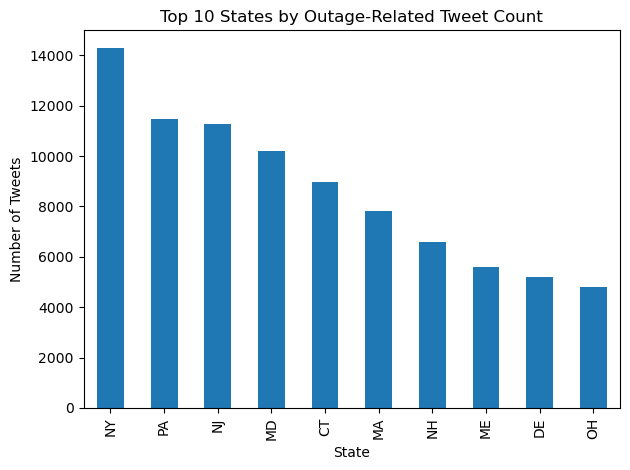

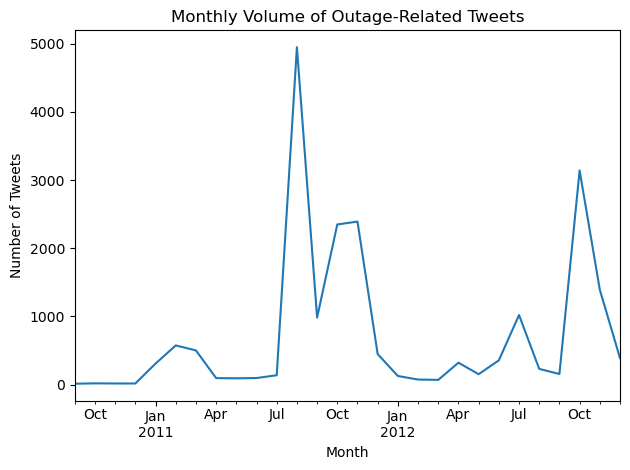

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# — UPDATE THIS to point at your CSV —
file_path = 'combined_tweets_outages.csv'

# Load and preprocess
df = pd.read_csv(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
outage_tweets = df[df['outage'] == 1].copy()

# Expand multi-state entries
outage_tweets['state_list'] = outage_tweets['outage_state'].str.split()
exploded = outage_tweets.explode('state_list')

# 1) Bar chart: top 10 states
state_counts = exploded['state_list'].value_counts()
plt.figure()
state_counts.head(10).plot(kind='bar')
plt.title('Top 10 States by Outage-Related Tweet Count')
plt.xlabel('State')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.savefig("top_states_with_outage.png", dpi=600)
plt.show()

# 2) Monthly time series of outage tweets
monthly_counts = (
    outage_tweets
    .set_index('timestamp')
    .resample('M')
    .size()
)
plt.figure()
monthly_counts.plot()
plt.title('Monthly Volume of Outage-Related Tweets')
plt.xlabel('Month')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.savefig("monthly_outage_numbers.png", dpi=600)
plt.show()

In [93]:
outages_df = df
outages_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38069 entries, 0 to 38068
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     38069 non-null  datetime64[ns]
 1   id            38069 non-null  int64         
 2   likes         38069 non-null  int64         
 3   query         38069 non-null  object        
 4   replies       20159 non-null  float64       
 5   retweets      38069 non-null  int64         
 6   text          38069 non-null  object        
 7   user          38069 non-null  object        
 8   outage        38069 non-null  int64         
 9   outage_state  20404 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 2.9+ MB


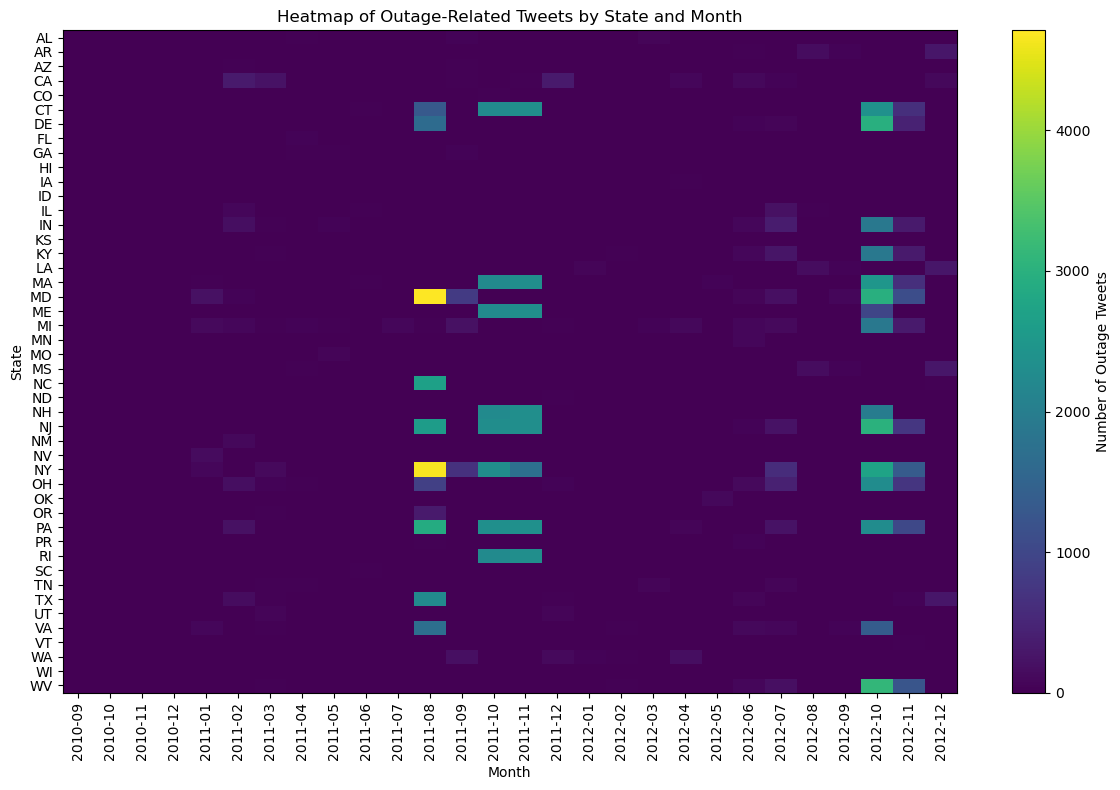

TypeError: 'float' object is not iterable

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations

# — UPDATE this path to where your CSV is located —
file_path = 'combined_tweets_outages.csv'

# Load and filter outage tweets
df = pd.read_csv(file_path, parse_dates=['timestamp'])
outage = df[df['outage'] == 1].copy()

# Explode multi-state entries into individual rows
outage['state_list'] = outage['outage_state'].str.split()
exploded = outage.explode('state_list')

# 1) State–Month Heatmap of Outage Tweets
exploded['month'] = exploded['timestamp'].dt.to_period('M')
pivot = exploded.groupby(['state_list','month']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
plt.imshow(pivot, aspect='auto', interpolation='nearest')
plt.xticks(range(len(pivot.columns)), [str(m) for m in pivot.columns], rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label='Number of Outage Tweets')
plt.title('Heatmap of Outage-Related Tweets by State and Month')
plt.xlabel('Month')
plt.ylabel('State')
plt.tight_layout()
plt.savefig("heatmap_DOE_outage.png", dpi=600)
plt.show()

# 2) State Co-occurrence Network
# Build a graph where states co-mentioned during the same tweet are connected
G = nx.Graph()
for states in outage['state_list']:
    unique_states = set(states)
    for s1, s2 in combinations(sorted(unique_states), 2):
        if G.has_edge(s1, s2):
            G[s1][s2]['weight'] += 1
        else:
            G.add_edge(s1, s2, weight=1)

# Filter edges by minimum co-occurrence threshold
threshold = 50
H = nx.Graph(
    [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > threshold]
)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(H, seed=42)
edge_widths = [d['weight'] / 20 for _, _, d in H.edges(data=True)]
nx.draw(H, pos,
        with_labels=True,
        node_size=3000,
        width=edge_widths,
        edge_cmap=plt.cm.OrRd)
plt.title(f'State Co-Occurrence Network (edges > {threshold} co-mentions)')
plt.tight_layout()

plt.show()



In [35]:
pwd

'G:\\My Drive\\WVU_academic\\EE-593A\\project\\input_files'

In [89]:
raw_outage = pd.read_csv("Grid_Disruption_00_14_standardized_cleaned.csv")

raw_outage.columns

Index(['Event Description', 'Year', 'Date Event Began', 'Time Event Began',
       'Date of Restoration', 'Time of Restoration', 'Respondent',
       'Geographic Areas', 'NERC Region', 'Demand Loss (MW)',
       'Number of Customers Affected', 'Tags'],
      dtype='object')

In [91]:
raw_outage.head()

,Event Description,Year,Date Event Began,Time Event Began,Date of Restoration,Time of Restoration,Respondent,Geographic Areas,NERC Region,Demand Loss (MW),Number of Customers Affected,Tags
0,Severe Weather - Thunderstorms,2014,6/30/2014,8:00 PM,7/2/2014,6:30 PM,Exelon Corporation/ComEd,Illinois,RFC,Unknown,420000.0,"severe weather, thunderstorm"
1,Severe Weather - Thunderstorms,2014,6/30/2014,11:20 PM,7/1/2014,5:00 PM,Northern Indiana Public Service Company,North Central Indiana,RFC,Unknown,127000.0,"severe weather, thunderstorm"
2,Severe Weather - Thunderstorms,2014,6/30/2014,5:55 PM,7/1/2014,2:53 AM,We Energies,Southeast Wisconsin,MRO,424,120000.0,"severe weather, thunderstorm"
3,Fuel Supply Emergency - Coal,2014,6/27/2014,1:21 PM,Unknown,Unknown,We Energies,Wisconsin,MRO,Unknown,NaN,"fuel supply emergency, coal"
4,Physical Attack - Vandalism,2014,6/24/2014,2:54 PM,6/24/2014,2:55 PM,Tennessee Valley Authority,"Nashville, Tennessee",SERC,Unknown,NaN,"vandalism, physical"


In [94]:
raw_outage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Event Description             1639 non-null   object 
 1   Year                          1639 non-null   int64  
 2   Date Event Began              1639 non-null   object 
 3   Time Event Began              1630 non-null   object 
 4   Date of Restoration           1625 non-null   object 
 5   Time of Restoration           1619 non-null   object 
 6   Respondent                    1639 non-null   object 
 7   Geographic Areas              1638 non-null   object 
 8   NERC Region                   1637 non-null   object 
 9   Demand Loss (MW)              1242 non-null   object 
 10  Number of Customers Affected  1221 non-null   float64
 11  Tags                          1638 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 153.8+ KB


In [26]:
cd G:\My Drive\WVU_academic\EE-593A\project\input_files

G:\My Drive\WVU_academic\EE-593A\project\input_files


Dropping 22 invalid rows with start > end


C:\Users\mr00065\AppData\Local\Temp\ipykernel_384\615996797.py:72: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 1000x500 with 0 Axes>

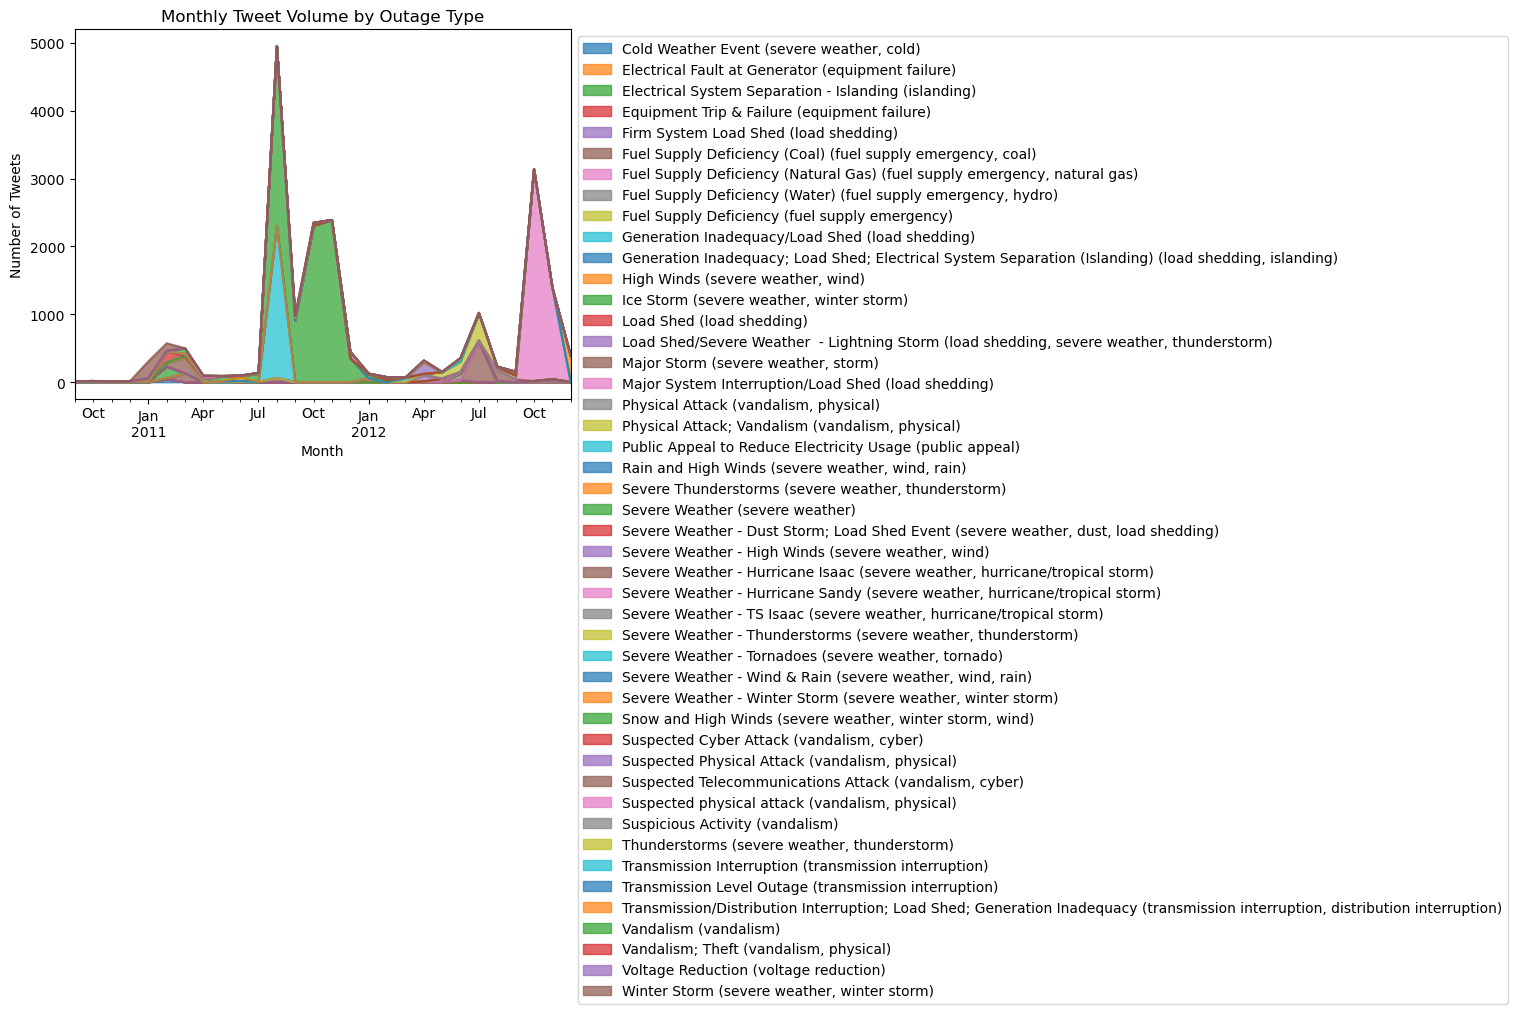

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# — Update these paths to your files —
tweets_path  = 'combined_tweets_outages.csv'
outages_path = 'Grid_Disruption_00_14_standardized_cleaned.csv'

# 1) Load and filter tweets to only those during an outage
tweets = pd.read_csv(tweets_path, parse_dates=['timestamp'])
tweets = tweets[tweets['outage'] == 1].copy()

# 2) Load the official outage records
raw = pd.read_csv(outages_path, dtype=str)

# 3) Parse full start/end datetimes
raw['Outage Start'] = pd.to_datetime(
    raw['Date Event Began'] + ' ' + raw['Time Event Began'],
    errors='coerce'
)
raw['Outage End']   = pd.to_datetime(
    raw['Date of Restoration'] + ' ' + raw['Time of Restoration'],
    errors='coerce'
)

# 4) Drop any rows missing a valid interval
raw = raw.dropna(subset=['Outage Start','Outage End']).reset_index(drop=True)

# 5) Drop intervals where start > end
mask_valid = raw['Outage Start'] <= raw['Outage End']
if not mask_valid.all():
    print(f"Dropping {(~mask_valid).sum()} invalid rows with start > end")
raw = raw[mask_valid].copy()

# 6) Build a single “outage_type” field for convenience
raw['outage_type'] = raw['Event Description'] + ' (' + raw['Tags'] + ')'

# 7) Initialize every tweet’s outage_type to Unknown
tweets['outage_type'] = 'Unknown'

# 8) For each outage event, mark tweets in that window
for _, row in raw.iterrows():
    start, end, cause = row['Outage Start'], row['Outage End'], row['outage_type']
    mask = (tweets['timestamp'] >= start) & (tweets['timestamp'] <= end)
    tweets.loc[mask, 'outage_type'] = cause

# —— Now the visualizations —— #

# A) Bar chart: Top 8 outage types by tweet count
# type_counts = tweets['outage_type'].value_counts().head(8)
# plt.figure(figsize=(8,4))
# type_counts.plot.barh()
# # plt.title("Top 8 Outage Types Mentioned in Tweets")
# plt.xlabel("Number of Tweets")
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.savefig("Outage_type.png", dpi=600)
# plt.show()

# # B) Stacked‐area time series: tweets per outage type over time
ts = tweets.set_index('timestamp')
monthly_by_type = (
    ts.groupby([pd.Grouper(freq='M'),'outage_type'])
      .size()
      .unstack(fill_value=0)
)
plt.figure(figsize=(10,5))
monthly_by_type.plot.area(alpha=0.7)
plt.title("Monthly Tweet Volume by Outage Type")
plt.ylabel("Number of Tweets")
plt.xlabel("Month")
plt.legend(loc='upper left', bbox_to_anchor=(1.0,1.0))
plt.tight_layout()
plt.savefig("monthly_tweets_outages.png", dpi=600)
plt.show()

# # C) Heatmap: states vs. outage types
# tweets['state_list'] = tweets['outage_state'].str.split()
# exploded = tweets.explode('state_list').dropna(subset=['state_list'])

# pivot = pd.pivot_table(
#     exploded,
#     index='state_list',
#     columns='outage_type',
#     aggfunc='size',
#     fill_value=0
# )

# plt.figure(figsize=(12,8))
# plt.imshow(pivot, aspect='auto', cmap='viridis')
# plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha='right')
# plt.yticks(range(len(pivot.index)), pivot.index)
# plt.colorbar(label='Tweet Count')
# plt.title("Heatmap of Outage Tweets by State and Type")
# plt.tight_layout()
# plt.show()

C:\Users\mr00065\AppData\Local\Temp\ipykernel_384\1992537892.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


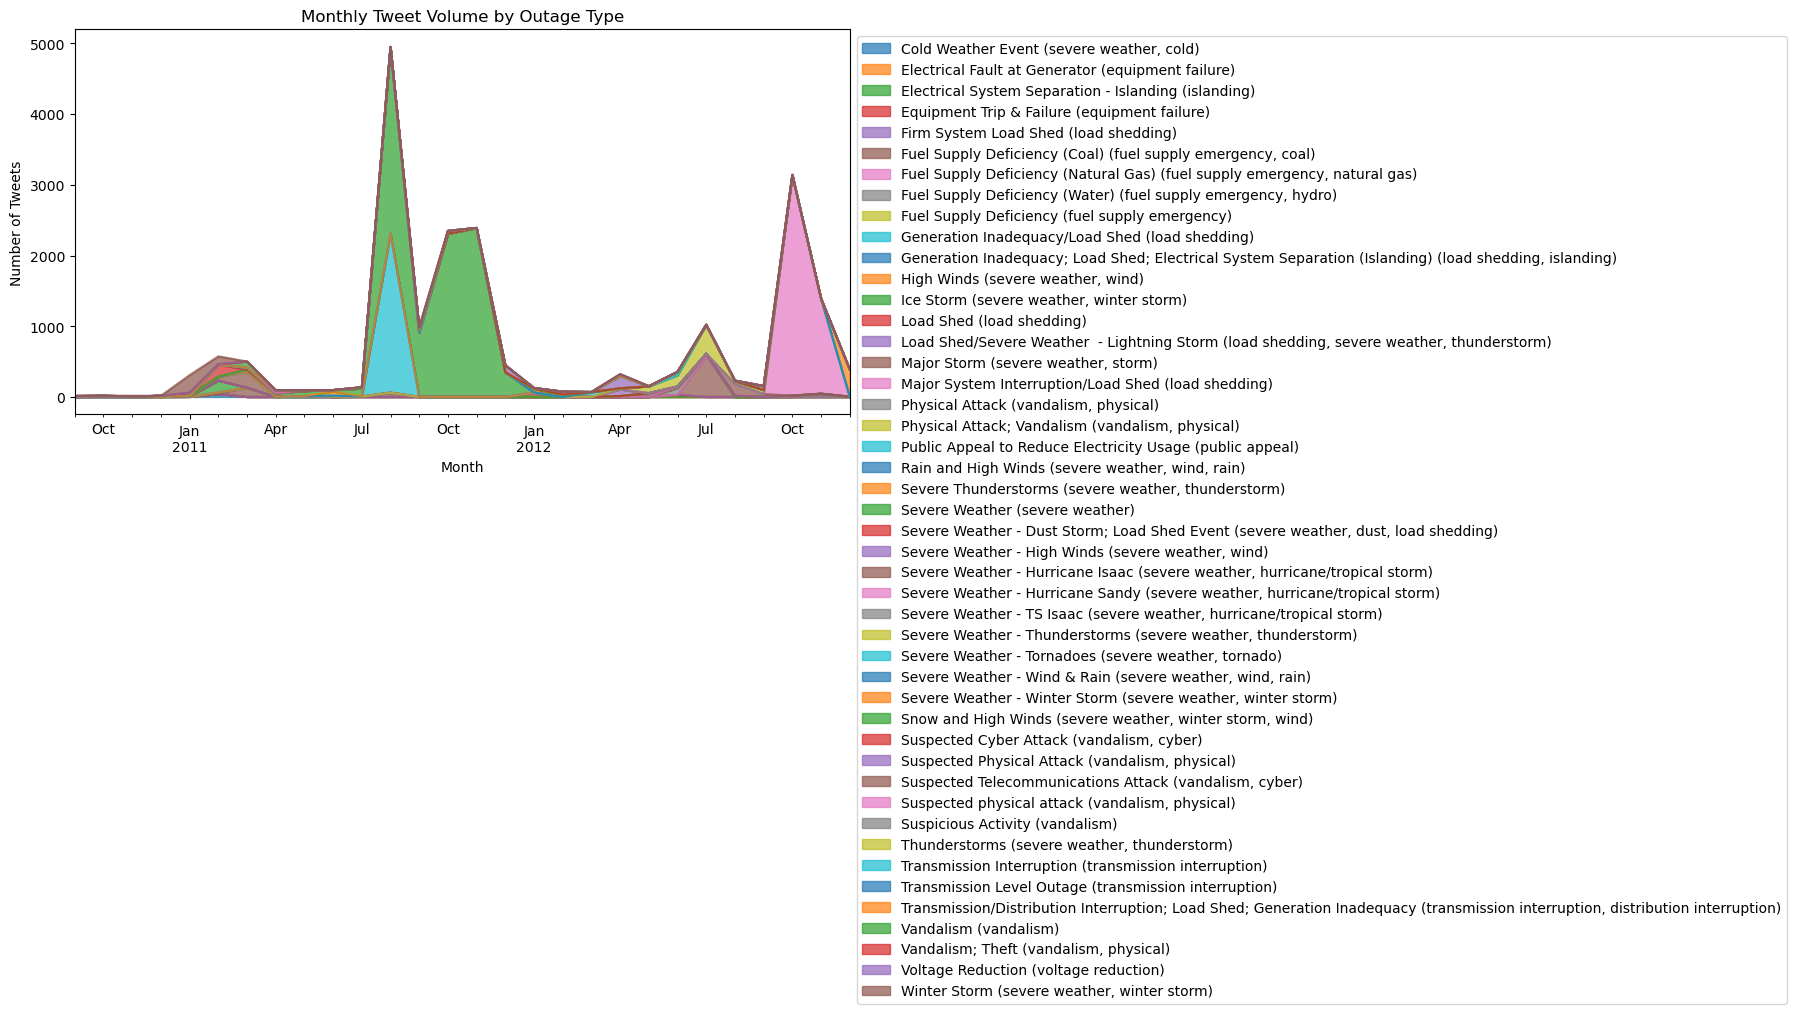

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

ts = tweets.set_index('timestamp')
monthly_by_type = (
    ts
    .groupby([pd.Grouper(freq='M'), 'outage_type'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
monthly_by_type.plot.area(ax=ax, alpha=0.7)
ax.set_title("Monthly Tweet Volume by Outage Type")
ax.set_ylabel("Number of Tweets")
ax.set_xlabel("Month")

lgd = ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()

fig.savefig(
    "monthly_tweets_outages.png",
    dpi=600,
    bbox_extra_artists=(lgd,),
    bbox_inches='tight'
)
plt.show()

In [100]:
tweets

,timestamp,id,likes,query,replies,retweets,text,user,outage,outage_state,outage_type,state_list
0,2012-11-01 23:50:22,264152432282578945,1,EversourceMA OR EversourceNH OR VelcoVT OR nat...,1.0,3,"Tom May, CEO of Northeast Utilities, the paren...",EversourceMA,1,WV OH PA NJ CT MA NY DE MD IN KY MI,Severe Weather - Hurricane Sandy (severe weath...,"[WV, OH, PA, NJ, CT, MA, NY, DE, MD, IN, KY, MI]"
1,2012-11-01 23:45:13,264151136792109056,0,EversourceMA OR EversourceNH OR VelcoVT OR nat...,0.0,0,@NYGovCuomo @lipanews @nationalgridus @nyseand...,readyforthenet,1,WV OH PA NJ CT MA NY DE MD IN KY MI,Severe Weather - Hurricane Sandy (severe weath...,"[WV, OH, PA, NJ, CT, MA, NY, DE, MD, IN, KY, MI]"
2,2012-11-01 23:34:44,264148498352590849,1,EversourceMA OR EversourceNH OR VelcoVT OR nat...,0.0,1,Some amazing video from the Wareham microburst...,EversourceMA,1,WV OH PA NJ CT MA NY DE MD IN KY MI,Severe Weather - Hurricane Sandy (severe weath...,"[WV, OH, PA, NJ, CT, MA, NY, DE, MD, IN, KY, MI]"
3,2012-11-01 23:34:20,264148399190851584,0,EversourceMA OR EversourceNH OR VelcoVT OR nat...,0.0,0,@nationalgridus Call me if you need some help ...,sparky1000,1,WV OH PA NJ CT MA NY DE MD IN KY MI,Severe Weather - Hurricane Sandy (severe weath...,"[WV, OH, PA, NJ, CT, MA, NY, DE, MD, IN, KY, MI]"
4,2012-11-01 23:31:56,264147793147490304,0,EversourceMA OR EversourceNH OR VelcoVT OR nat...,1.0,8,Current PSNH statewide w/o power: 885. We're d...,EversourceNH,1,WV OH PA NJ CT MA NY DE MD IN KY MI,Severe Weather - Hurricane Sandy (severe weath...,"[WV, OH, PA, NJ, CT, MA, NY, DE, MD, IN, KY, MI]"
...,...,...,...,...,...,...,...,...,...,...,...,...
38044,2012-02-20 04:28:00,171526721961598976,0,VT,NaN,0,"""To God our Savior, Who alone is wise, Be glor...",ldavidptl,1,KY VA WV,"Severe Weather - Winter Storm (severe weather,...","[KY, VA, WV]"
38046,2012-02-15 11:54:00,169826965656838144,0,VT,NaN,0,@LittleJazzlyn Wow--your voice reminds me of t...,StephHodges72,1,WA,"Suspected Physical Attack (vandalism, physical)",[WA]
38047,2012-02-15 04:15:00,169711318193025024,0,VT,NaN,0,Mornings are my favorite time of the day. Than...,ldavidptl,1,WA,"Suspected Physical Attack (vandalism, physical)",[WA]
38062,2012-01-19 08:15:00,159987340826251264,0,VT,NaN,0,Deuteronomy 8:17-18 ()\n17 Beware lest you say...,n2fordtrucks,1,WA,"Severe Weather - Winter Storm (severe weather,...",[WA]


In [118]:
import pandas as pd

outage_check = pd.read_csv("MA_monthlytweets.csv")
outage_check.head()

,Screen Name,Status ID,Text,Local Timestamp,Likes,Retweets,State
0,BOS311,2.050441e+16,"Closed report at 169-199 Mountfort St, Brookli...",10:40 AM - 30 Dec 2010,Like\n \n \n \n \n \n \n ...,Retweet\n \n \n \n \n \n \n ...,MA
1,BOS311,2.049531e+16,"Closed report at 157-167 Milk St, Boston: http...",10:03 AM - 30 Dec 2010,Like\n \n \n \n \n \n \n ...,Retweet\n \n \n \n \n \n \n ...,MA
2,pyyhkala,1.944947e+16,Out about Acton appears not even like a 5 year...,12:48 PM - 27 Dec 2010,Like\n \n \n \n \n \n \n ...,Retweet\n \n \n \n \n \n \n ...,MA
3,thepennyhoarder,1.082664e+18,There's a secret bank paying 100x the normal i...,10:41 AM - 8 Jan 2019,Like\n \n \n 14\n \n \n \n ...,Retweet\n \n \n 2\n \n \n \n ...,MA
4,Skeetz8,1.940686e+16,Yoo this storm is #killing niggas. Ain't shit ...,9:58 AM - 27 Dec 2010,Like\n \n \n \n \n \n \n ...,Retweet\n \n \n 3\n \n \n \n ...,MA


In [119]:
outage_check.columns

Index(['Screen Name', 'Status ID', 'Text', 'Local Timestamp', 'Likes',
       'Retweets', 'State'],
      dtype='object')

In [117]:
import pandas as pd
import re



import pandas as pd
import re

df = pd.read_csv('validation_dataset.csv')
state_full = ['Maine', 'Massachusetts', 'New Hampshire', 'Vermont', 'Connecticut', 'Rhode Island', 'New York']
pattern = r'\b(' + '|'.join(state_full) + r')\b'

mask = df['Geographic Areas'].str.contains(pattern, case=False, na=False)
df7 = df[mask].copy()
df7['State'] = df7['Geographic Areas'].str.extract(pattern, flags=re.IGNORECASE)[0].str.title()

for st in state_full:
    subset = df7[df7['State'] == st]
    subset.to_csv(f'doe_outages_{st.replace(" ", "_")}.csv', index=False)

C:\Users\mr00065\AppData\Local\Temp\ipykernel_13436\2055208780.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['Geographic Areas'].str.contains(pattern, case=False, na=False)


In [123]:
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from evaluate import load as load_metric

metric = load_metric('accuracy')
# load labeled data
label_df = pd.read_csv('MA_monthlytweets.csv')  # must have 'Text' and 'label' columns
dataset = Dataset.from_pandas(label_df[['Text', 'label']])

# train/validation split
dataset = dataset.train_test_split(test_size=0.2)

# tokenizer setup
tokenizer = AutoTokenizer.from_pretrained('vinai/bertweet-base', use_fast=True)

def preprocess(batch):
    return tokenizer(batch['Text'], padding=True, truncation=True, max_length=128)

tokenized = dataset.map(preprocess, batched=True)

# model initialization
model = AutoModelForSequenceClassification.from_pretrained('vinai/bertweet-base', num_labels=2)

# training arguments
training_args = TrainingArguments(
    output_dir='results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    evaluation_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy'
)

# metric definition
metric = load_metric('accuracy')
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return metric.compute(predictions=preds, references=labels)

# trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

# apply model to full tweet set
df_full = pd.read_csv('MA_monthlytweets.csv')
full_ds = Dataset.from_pandas(df_full[['Text']])
tokenized_full = full_ds.map(preprocess, batched=True)
preds = trainer.predict(tokenized_full)
df_full['outage_status'] = np.argmax(preds.predictions, axis=-1)

df_full.to_csv('MA_monthlytweets_with_outage_status.csv', index=False)


RuntimeError: Failed to import transformers.trainer because of the following error (look up to see its traceback):
Failed to import transformers.integrations.integration_utils because of the following error (look up to see its traceback):
Failed to import transformers.modeling_utils because of the following error (look up to see its traceback):
module 'torch' has no attribute 'compiler'

In [39]:
import pandas as pd

csv_path = r"G:\My Drive\WVU_academic\EE-593A\project\input_files\combined_tweets_outages_cities_states.csv"

df = pd.read_csv(csv_path)
df.head()

,timestamp,id,query,text,user,outage,outage_state,city_pull,text_state_pull,user_state_pull
0,2012-11-01 23:50:22,264152432282578945,EversourceMA OR EversourceNH OR VelcoVT OR nat...,"Tom May, CEO of Northeast Utilities, the paren...",EversourceMA,1,WV OH PA NJ CT MA NY DE MD IN KY MI,"['Sudbury, MA', 'Sudbury, VT']",NaN,MA
1,2012-11-01 23:45:13,264151136792109056,EversourceMA OR EversourceNH OR VelcoVT OR nat...,@NYGovCuomo @lipanews @nationalgridus @nyseand...,readyforthenet,1,WV OH PA NJ CT MA NY DE MD IN KY MI,NaN,NY,NaN
2,2012-11-01 23:34:44,264148498352590849,EversourceMA OR EversourceNH OR VelcoVT OR nat...,Some amazing video from the Wareham microburst...,EversourceMA,1,WV OH PA NJ CT MA NY DE MD IN KY MI,"['Wareham, MA', 'Dartmouth, MA']",NaN,MA
3,2012-11-01 23:34:20,264148399190851584,EversourceMA OR EversourceNH OR VelcoVT OR nat...,@nationalgridus Call me if you need some help ...,sparky1000,1,WV OH PA NJ CT MA NY DE MD IN KY MI,NaN,NaN,NaN
4,2012-11-01 23:31:56,264147793147490304,EversourceMA OR EversourceNH OR VelcoVT OR nat...,Current PSNH statewide w/o power: 885. We're d...,EversourceNH,1,WV OH PA NJ CT MA NY DE MD IN KY MI,NaN,NH,NH


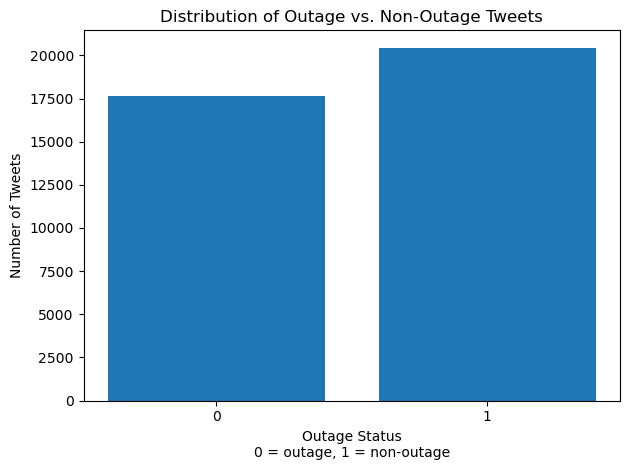

In [40]:
import matplotlib.pyplot as plt
df['timestamp'] = pd.to_datetime(df['timestamp'])
# —— Visualization 1: Outage vs. Non-Outage Counts —— #
status_counts = df['outage'].value_counts().sort_index()
fig, ax = plt.subplots()
ax.bar(status_counts.index.astype(str), status_counts.values)
ax.set_xlabel('Outage Status\n0 = outage, 1 = non-outage')
ax.set_ylabel('Number of Tweets')
ax.set_title('Distribution of Outage vs. Non-Outage Tweets')
plt.tight_layout()
plt.savefig("distribution_of_outage_non_outage.png", dpi=600)
plt.show()

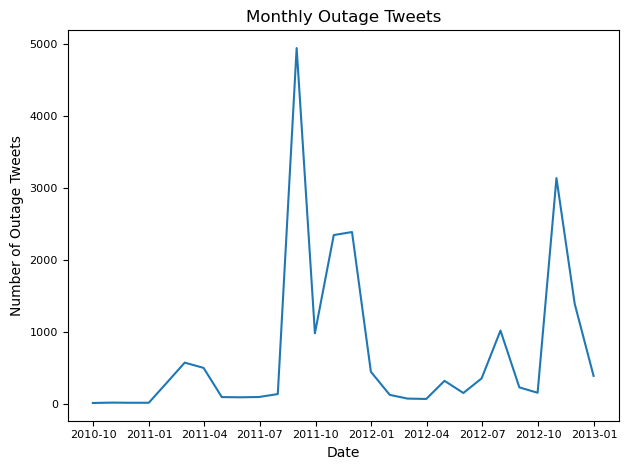

In [13]:
# 0) Load and preprocess
out = df[df["outage"] == 1]  # keep only outage‐related tweets

# 1) Outages over time (monthly)
monthly_out = out.set_index("timestamp").resample("M").size()
fig, ax = plt.subplots()
ax.plot(monthly_out.index, monthly_out.values)
ax.set_title("Monthly Outage Tweets")
ax.set_xlabel("Date")
ax.tick_params(axis='x', labelsize=8)
ax.set_ylabel("Number of Outage Tweets")
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

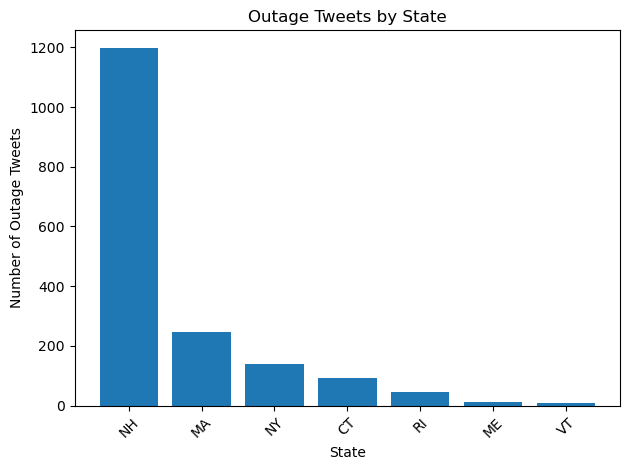

In [14]:
# 2) Outages by State
# use whichever state column you trust most (here I use user_state_pull)
state_counts = out["user_state_pull"].dropna().value_counts()
fig, ax = plt.subplots()
ax.bar(state_counts.index, state_counts.values)
ax.set_title("Outage Tweets by State")
ax.set_xlabel("State")
ax.set_ylabel("Number of Outage Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

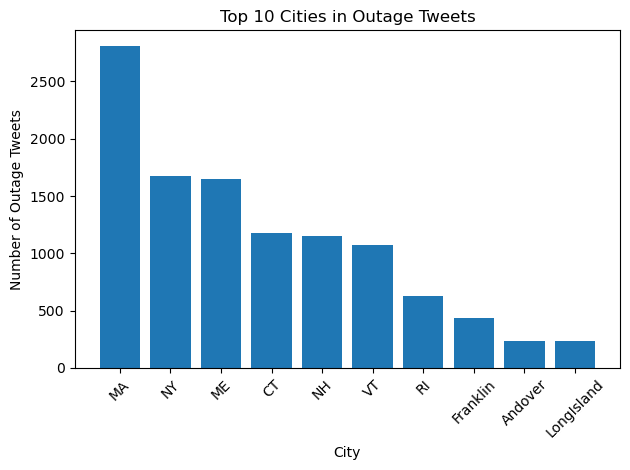

In [15]:
# 3) Outages by City (top 10)
# assuming city_pull is a stringified list like "['City, ST', ...]"
cities = (
    out["city_pull"]
      .dropna()
      .str.strip("[]")
      .str.replace("'", "")
      .str.split(", ")
      .explode()
)
city_counts = cities.value_counts().head(10)
fig, ax = plt.subplots()
ax.bar(city_counts.index, city_counts.values)
ax.set_title("Top 10 Cities in Outage Tweets")
ax.set_xlabel("City")
ax.set_ylabel("Number of Outage Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Now, I have the similar csv files for 5 other states with target_states = ['MA','ME','NH','NY','VT','CT']. How can I have all of them at the same figures for different times, like done in the following code for morning, noon etc..

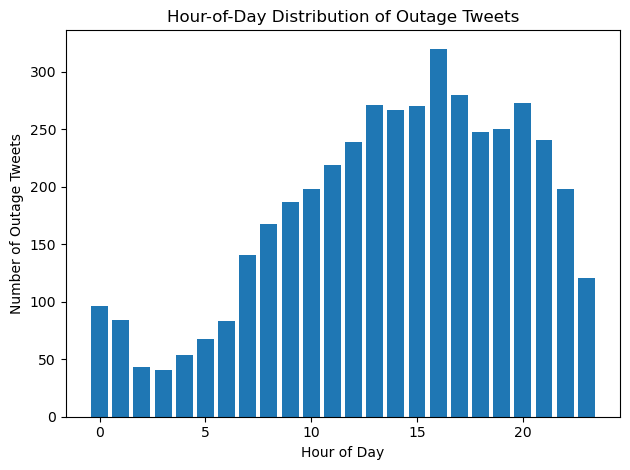

In [42]:
# 4) Hour‐of‐Day Pattern for Outages
hourly = out["timestamp"].dt.hour.value_counts().sort_index()
fig, ax = plt.subplots()
ax.bar(hourly.index, hourly.values)
ax.set_title("Hour-of-Day Distribution of Outage Tweets")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Outage Tweets")
plt.tight_layout()
plt.savefig("average_daily_tweets_on_outages.png", dpi=600)
plt.show()

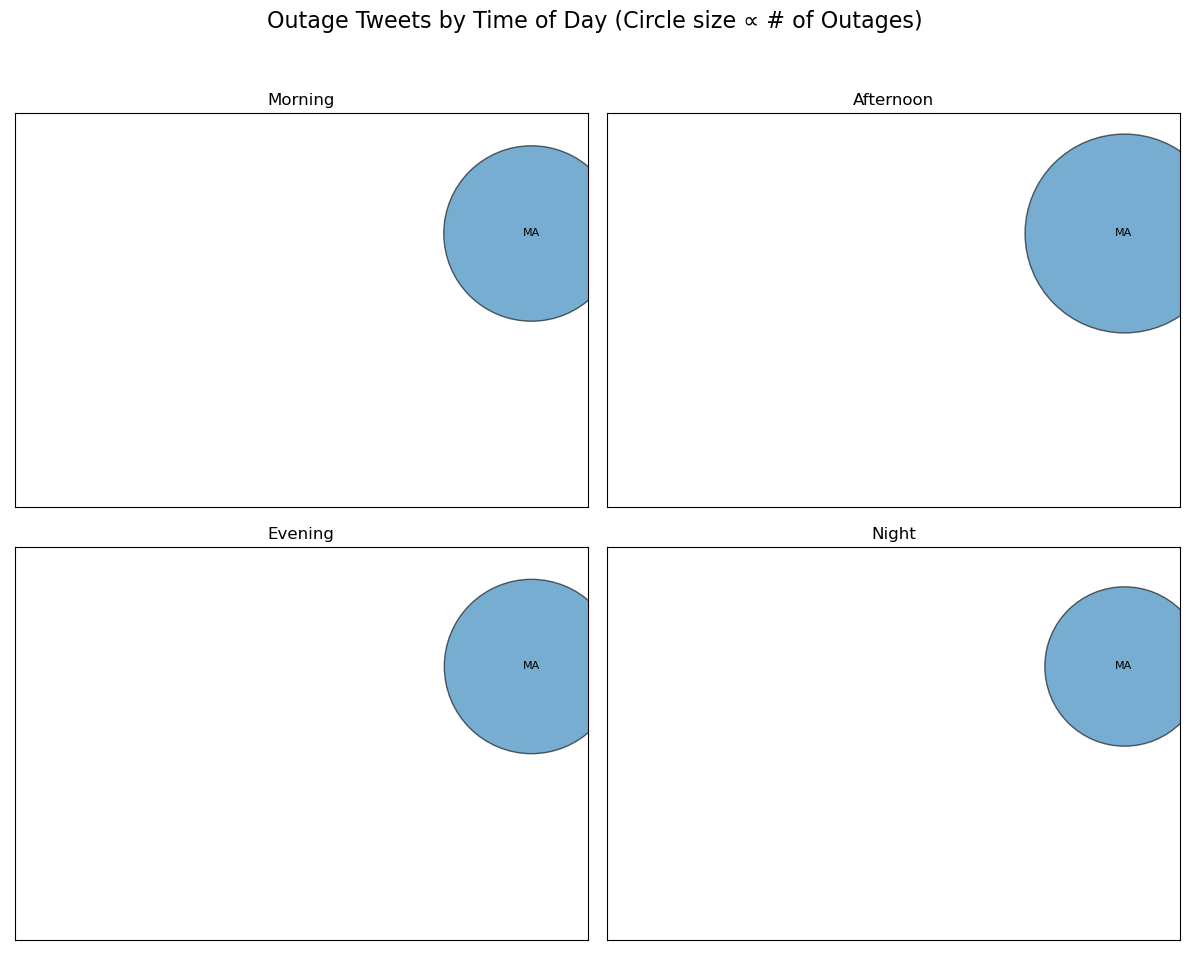

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"G:\My Drive\WVU_academic\EE-593A\project\input_files\MA_monthlytweets_with_outage.csv"
df   = pd.read_csv(path)
def parse_ts(ts):
    try:
        # matches "10:40 AM - 30 Dec 2010"
        return pd.to_datetime(ts, format="%I:%M %p - %d %b %Y")
    except ValueError:
        # fallback to any reasonable format
        return pd.to_datetime(ts, infer_datetime_format=True, dayfirst=False, errors="coerce")

df["timestamp"] = df["Local Timestamp"].apply(parse_ts)
df["hour"]      = df["timestamp"].dt.hour

# 3) Extract the hour (0–23)
# df['hour'] = df['timestamp'].dt.hour
out  = df[df["Outage_status"] == 1].copy()
out["hour"] = out["timestamp"].dt.hour

# 2) State centroids for plotting (lon, lat)
state_centroids = {
    'AL': (-86.9, 32.3), 'AK': (-152.4, 61.4), 'AZ': (-111.1, 34.0),
    'AR': (-92.4, 35.0), 'CA': (-119.4, 36.8), 'CO': (-105.8, 39.6),
    'CT': (-72.8, 41.6), 'DE': (-75.5, 38.9), 'FL': (-81.5, 27.7),
    'GA': (-82.9, 32.2), 'HI': (-155.6, 19.9), 'ID': (-114.7, 44.1),
    'IL': (-89.4, 40.6), 'IN': (-86.1, 40.3), 'IA': (-93.1, 41.9),
    'KS': (-98.5, 39.0), 'KY': (-84.3, 37.8), 'LA': (-91.9, 31.0),
    'ME': (-69.4, 45.3), 'MD': (-76.6, 39.0), 'MA': (-71.4, 42.4),
    'MI': (-85.6, 44.3), 'MN': (-94.7, 46.7), 'MS': (-89.4, 32.4),
    'MO': (-91.8, 38.0), 'MT': (-110.4, 46.9), 'NE': (-99.9, 41.5),
    'NV': (-116.4, 38.8), 'NH': (-71.6, 43.2), 'NJ': (-74.4, 40.1),
    'NM': (-105.9, 34.3), 'NY': (-74.2, 43.3), 'NC': (-79.0, 35.8),
    'ND': (-99.9, 47.6), 'OH': (-82.9, 40.4), 'OK': (-97.1, 35.0),
    'OR': (-120.6, 43.8), 'PA': (-77.2, 41.2), 'RI': (-71.5, 41.6),
    'SC': (-81.2, 33.8), 'SD': (-99.9, 44.3), 'TN': (-86.6, 35.5),
    'TX': (-99.9, 31.0), 'UT': (-111.1, 39.4), 'VT': (-72.6, 44.6),
    'VA': (-78.7, 37.4), 'WA': (-120.7, 47.8), 'WV': (-80.5, 38.6),
    'WI': (-88.8, 43.8), 'WY': (-107.3, 43.1)
}

# 3) Define your time‐of‐day bins
bins = {
    "Morning"  : range(5, 12),
    "Afternoon": range(12, 17),
    "Evening"  : range(17, 21),
    "Night"    : list(range(0, 5)) + list(range(21, 24))
}

# 4) Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for ax, (period, hours) in zip(axes.flatten(), bins.items()):
    subset = out[out["hour"].isin(hours)]
    counts = subset["State"].dropna().value_counts()

    # scatter each state centroid
    for st, cnt in counts.items():
        coord = state_centroids.get(st)
        if coord:
            lon, lat = coord
            ax.scatter(lon, lat, s=cnt * 15, alpha=0.6, edgecolor='k')
            ax.text(lon, lat, st, fontsize=8, ha="center", va="center")

    ax.set_title(period)
    ax.set_xlim(-130, -65)
    ax.set_ylim(25, 50)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Outage Tweets by Time of Day (Circle size ∝ # of Outages)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [25]:
df = pd.read_csv(r"G:\My Drive\WVU_academic\EE-593A\project\input_files\combined_tweets_outages.csv")
df.head()

,timestamp,id,likes,query,replies,retweets,text,user,outage,outage_state
0,2012-11-01 23:50:22,264152432282578945,1,EversourceMA OR EversourceNH OR VelcoVT OR nat...,1.0,3,"Tom May, CEO of Northeast Utilities, the paren...",EversourceMA,1,WV OH PA NJ CT MA NY DE MD IN KY MI
1,2012-11-01 23:45:13,264151136792109056,0,EversourceMA OR EversourceNH OR VelcoVT OR nat...,0.0,0,@NYGovCuomo @lipanews @nationalgridus @nyseand...,readyforthenet,1,WV OH PA NJ CT MA NY DE MD IN KY MI
2,2012-11-01 23:34:44,264148498352590849,1,EversourceMA OR EversourceNH OR VelcoVT OR nat...,0.0,1,Some amazing video from the Wareham microburst...,EversourceMA,1,WV OH PA NJ CT MA NY DE MD IN KY MI
3,2012-11-01 23:34:20,264148399190851584,0,EversourceMA OR EversourceNH OR VelcoVT OR nat...,0.0,0,@nationalgridus Call me if you need some help ...,sparky1000,1,WV OH PA NJ CT MA NY DE MD IN KY MI
4,2012-11-01 23:31:56,264147793147490304,0,EversourceMA OR EversourceNH OR VelcoVT OR nat...,1.0,8,Current PSNH statewide w/o power: 885. We're d...,EversourceNH,1,WV OH PA NJ CT MA NY DE MD IN KY MI


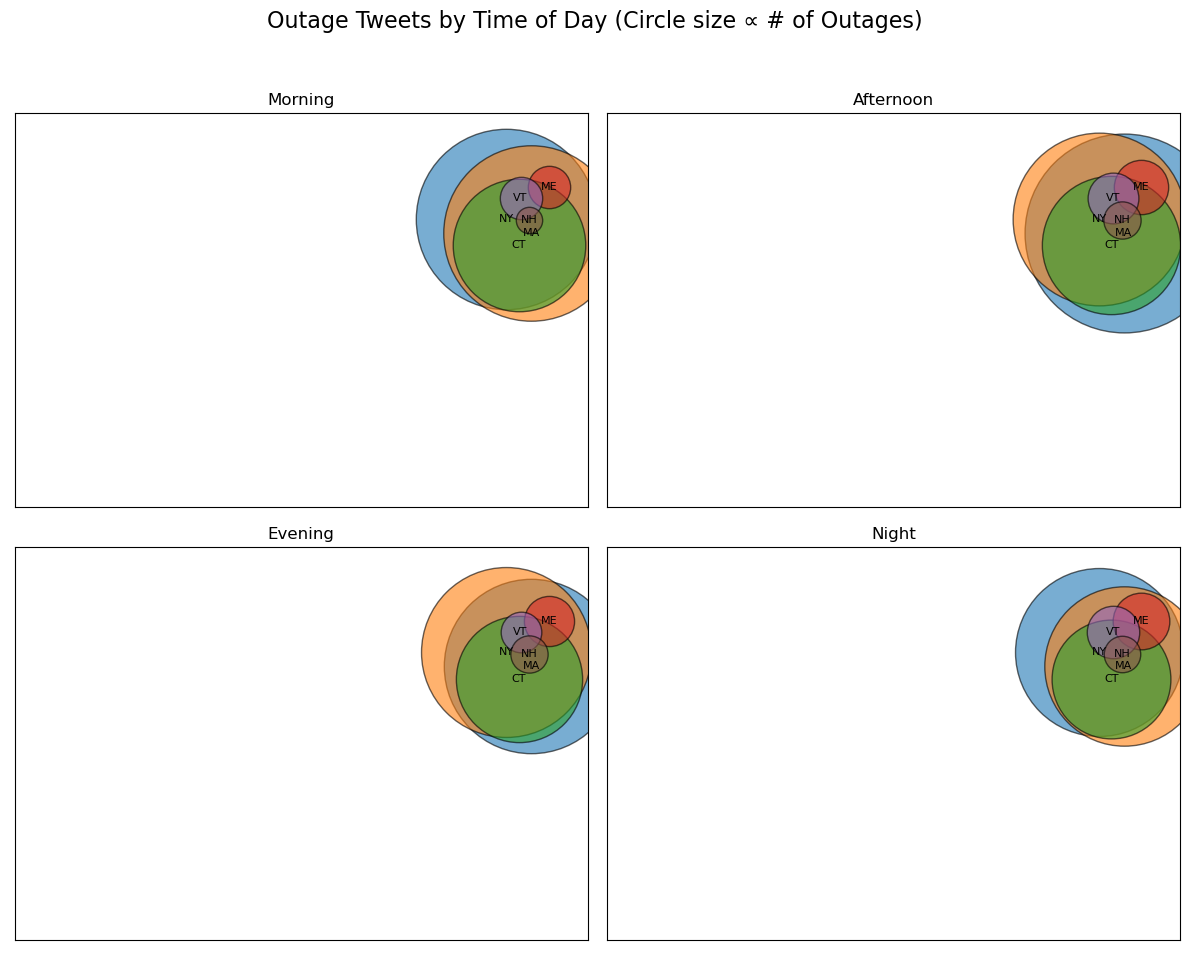

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

def parse_ts(ts):
    try:
        return pd.to_datetime(ts, format="%I:%M %p - %d %b %Y")
    except ValueError:
        return pd.to_datetime(ts, infer_datetime_format=True, dayfirst=False, errors="coerce")

states = ['MA','ME','NH','NY','VT','CT']
df_list = []
for st in states:
#     path = f"G:\My Drive\WVU_academic\EE-593A\project\input_files\CT_monthlytweets_with_outage.csv"
    path = f"G:/My Drive/WVU_academic/EE-593A/project/input_files/{st}_monthlytweets_with_outage.csv"
    df = pd.read_csv(path)
    df['State']     = st
    df['timestamp'] = df['Local Timestamp'].apply(parse_ts)
    df['hour']      = df['timestamp'].dt.hour
    df_list.append(df)

all_df = pd.concat(df_list, ignore_index=True)
out = all_df[all_df['Outage_status'] == 1].copy()
out['hour'] = out['timestamp'].dt.hour

state_centroids = {
    'CT': (-72.8, 41.6), 'MA': (-71.4, 42.4), 'ME': (-69.4, 45.3),
    'NH': (-71.6, 43.2), 'NY': (-74.2, 43.3), 'VT': (-72.6, 44.6),
    # … you can trim this dict down to just your six if you like
}

bins = {
    "Morning"  : range(5, 12),
    "Afternoon": range(12, 17),
    "Evening"  : range(17, 21),
    "Night"    : list(range(0, 5)) + list(range(21, 24))
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for ax, (period, hours) in zip(axes.flatten(), bins.items()):
    subset = out[out['hour'].isin(hours)]
    counts = subset['State'].value_counts()
    for st, cnt in counts.items():
        lon, lat = state_centroids.get(st)
        ax.scatter(lon, lat, s=cnt * 15, alpha=0.6, edgecolor='k')
        ax.text(lon, lat, st, fontsize=8, ha="center", va="center")
    ax.set_title(period)
    ax.set_xlim(-130, -65)
    ax.set_ylim(25, 50)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Outage Tweets by Time of Day (Circle size ∝ # of Outages)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("outage_by_time_pf_day.png", dpi=600)
plt.show()


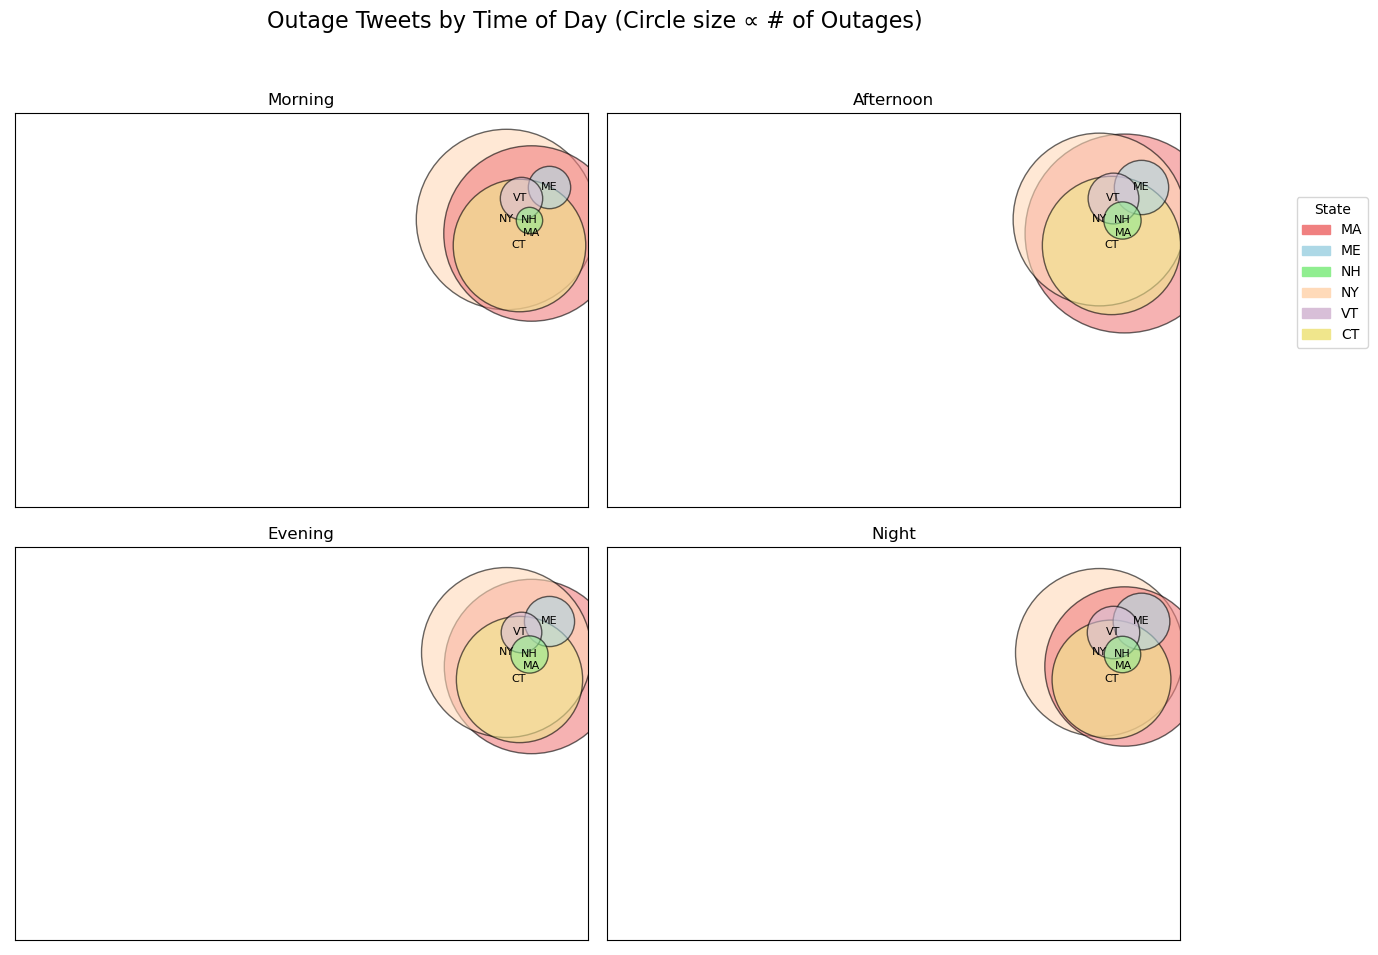

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def parse_ts(ts):
    try:
        return pd.to_datetime(ts, format="%I:%M %p - %d %b %Y")
    except ValueError:
        return pd.to_datetime(ts, infer_datetime_format=True, dayfirst=False, errors="coerce")

states = ['MA','ME','NH','NY','VT','CT']
df_list = []
for st in states:
    path = f"G:/My Drive/WVU_academic/EE-593A/project/input_files/{st}_monthlytweets_with_outage.csv"
    df = pd.read_csv(path)
    df['State']     = st
    df['timestamp'] = df['Local Timestamp'].apply(parse_ts)
    df['hour']      = df['timestamp'].dt.hour
    df_list.append(df)

all_df = pd.concat(df_list, ignore_index=True)
out    = all_df[all_df['Outage_status'] == 1].copy()
out['hour'] = out['timestamp'].dt.hour

state_centroids = {
    'MA': (-71.4, 42.4), 'ME': (-69.4, 45.3), 'NH': (-71.6, 43.2),
    'NY': (-74.2, 43.3), 'VT': (-72.6, 44.6), 'CT': (-72.8, 41.6),
}

state_colors = {
    'MA': 'lightcoral',
    'ME': 'lightblue',
    'NH': 'lightgreen',
    'NY': 'peachpuff',
    'VT': 'thistle',
    'CT': 'khaki',
}
bins = {
    "Morning"  : range(5, 12),
    "Afternoon": range(12, 17),
    "Evening"  : range(17, 21),
    "Night"    : list(range(0, 5)) + list(range(21, 24))
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for ax, (period, hours) in zip(axes.flatten(), bins.items()):
    subset = out[out['hour'].isin(hours)]
    counts = subset['State'].value_counts()
    for st, cnt in counts.items():
        lon, lat = state_centroids[st]
        ax.scatter(lon, lat,
                   s=cnt * 15,
                   color=state_colors[st],
                   alpha=0.6,
                   edgecolor='k')
        ax.text(lon, lat, st, fontsize=8, ha="center", va="center")
    ax.set_title(period)
    ax.set_xlim(-130, -65)
    ax.set_ylim(25, 50)
    ax.set_xticks([]); ax.set_yticks([])

handles = [
    mpatches.Patch(color=state_colors[st], label=st)
    for st in states
]
fig.legend(handles=handles, title="State", loc='upper right', bbox_to_anchor=(1.15, 0.8))

fig.suptitle("Outage Tweets by Time of Day (Circle size ∝ # of Outages)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("outage_tweets_by_time_of_day.png", dpi=600)
plt.show()

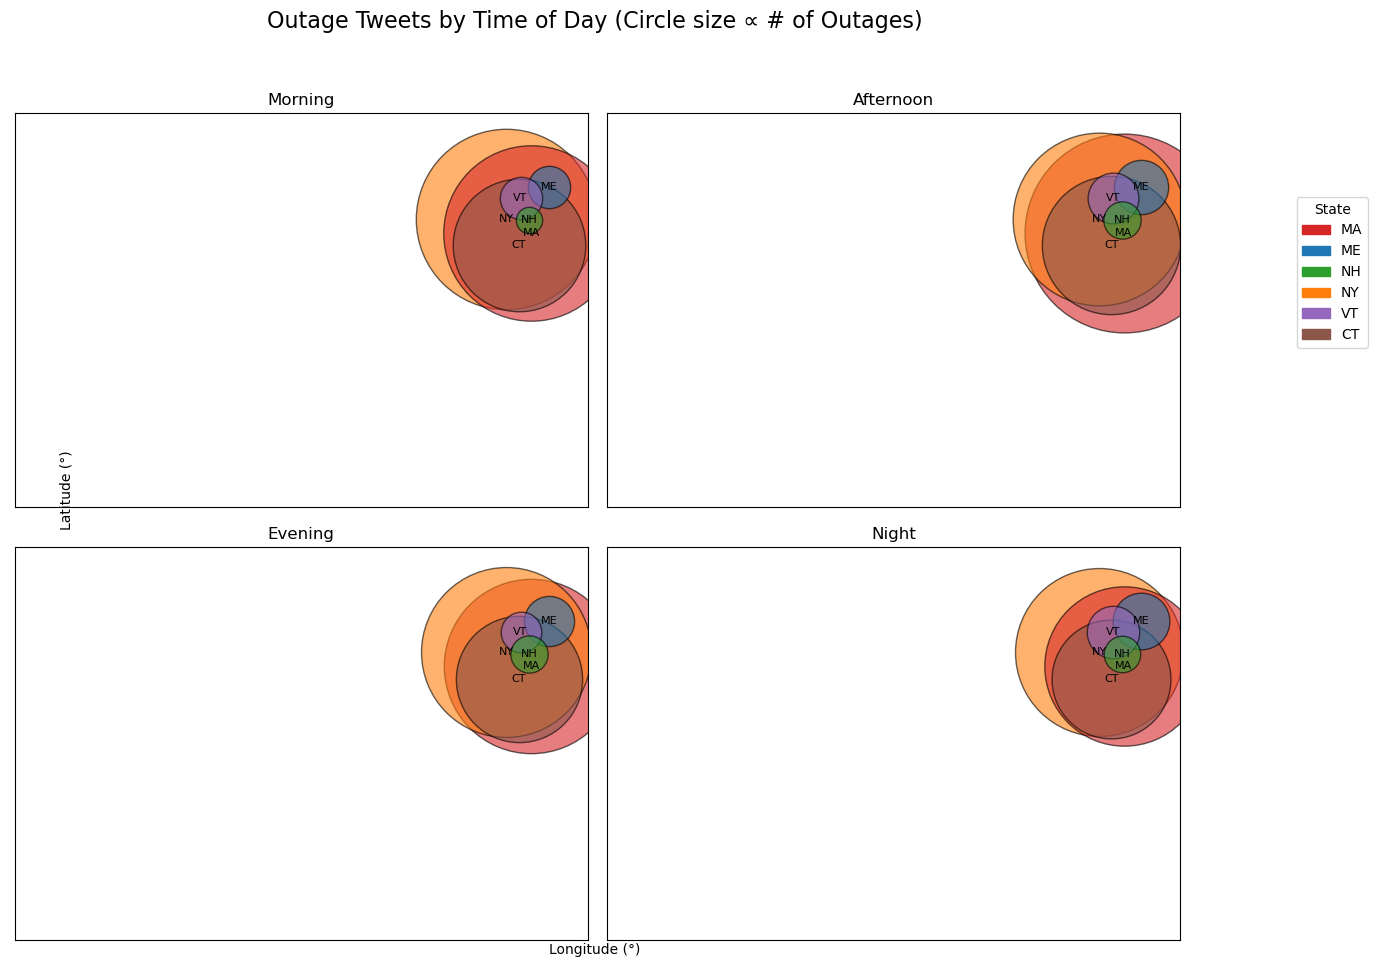

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def parse_ts(ts):
    try:
        return pd.to_datetime(ts, format="%I:%M %p - %d %b %Y")
    except ValueError:
        return pd.to_datetime(ts, infer_datetime_format=True, dayfirst=False, errors="coerce")

states = ['MA','ME','NH','NY','VT','CT']
df_list = []
for st in states:
    path = f"G:/My Drive/WVU_academic/EE-593A/project/input_files/{st}_monthlytweets_with_outage.csv"
    df = pd.read_csv(path)
    df['State']     = st
    df['timestamp'] = df['Local Timestamp'].apply(parse_ts)
    df['hour']      = df['timestamp'].dt.hour
    df_list.append(df)

all_df = pd.concat(df_list, ignore_index=True)
out    = all_df[all_df['Outage_status'] == 1].copy()
out['hour'] = out['timestamp'].dt.hour

state_centroids = {
    'MA': (-71.4, 42.4), 'ME': (-69.4, 45.3), 'NH': (-71.6, 43.2),
    'NY': (-74.2, 43.3), 'VT': (-72.6, 44.6), 'CT': (-72.8, 41.6),
}

state_colors = {
    'MA': 'tab:red',
    'ME': 'tab:blue',
    'NH': 'tab:green',
    'NY': 'tab:orange',
    'VT': 'tab:purple',
    'CT': 'tab:brown',
}

bins = {
    "Morning"  : range(5, 12),
    "Afternoon": range(12, 17),
    "Evening"  : range(17, 21),
    "Night"    : list(range(0, 5)) + list(range(21, 24))
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for ax, (period, hours) in zip(axes.flatten(), bins.items()):
    subset = out[out['hour'].isin(hours)]
    counts = subset['State'].value_counts()
    for st, cnt in counts.items():
        lon, lat = state_centroids[st]
        ax.scatter(lon, lat,
                   s=cnt * 15,
                   color=state_colors[st],
                   alpha=0.6,
                   edgecolor='k')
        ax.text(lon, lat, st, fontsize=8, ha="center", va="center")
    ax.set_title(period)
    ax.set_xlim(-130, -65)
    ax.set_ylim(25, 50)
    ax.set_xticks([])
    ax.set_yticks([])

handles = [
    mpatches.Patch(color=state_colors[st], label=st)
    for st in states
]
fig.legend(handles=handles, title="State", loc='upper right', bbox_to_anchor=(1.15, 0.8))

fig.suptitle("Outage Tweets by Time of Day (Circle size ∝ # of Outages)", fontsize=16)
fig.text(0.5, 0.04, 'Longitude (°)', ha='center', va='center')
fig.text(0.06, 0.5, 'Latitude (°)', ha='center', va='center', rotation='vertical')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [1]:
cd G:\My Drive\WVU_academic\EE-593A\project\input_files

G:\My Drive\WVU_academic\EE-593A\project\input_files


In [7]:
import pandas as pd
df_doe = pd.read_csv("Grid_Disruption_00_14_standardized_cleaned.csv")
df_doe.columns

# df_doe.info

Index(['Event Description', 'Year', 'Date Event Began', 'Time Event Began',
       'Date of Restoration', 'Time of Restoration', 'Respondent',
       'Geographic Areas', 'NERC Region', 'Demand Loss (MW)',
       'Number of Customers Affected', 'Tags'],
      dtype='object')

In [16]:
import pandas as pd
import re

df = df_doe.copy()

df['event_dt'] = pd.to_datetime(df['Date Event Began'].str.strip() + ' ' + df['Time Event Began'].fillna(''), errors='coerce')
df = df.loc[(df['event_dt'] >= '2009-09-01') & (df['event_dt'] <= '2012-12-31')]

state_map = {
    'Massachusetts': 'MA',
    'Maine': 'ME',
    'New Hampshire': 'NH',
    'New York': 'NY',
    'Vermont': 'VT',
    'Connecticut': 'CT'
}

def extract_state_code(text):
    for full, abbr in state_map.items():
        if pd.notna(text) and re.search(rf'\b{re.escape(full)}\b', text, re.IGNORECASE):
            return abbr
    return None

df['State'] = df['Geographic Areas'].apply(extract_state_code)
df = df[df['State'].notna()]
df['Event Date'] = df['event_dt'].dt.strftime('%m/%d/%Y')
df = df.sort_values(['event_dt', 'State'])
result = df[['Event Description','Year','Event Date','State']].copy()
result['Outage_status'] = 1

result.head()

,Event Description,Year,Event Date,State,Outage_status
897,Winter Storm,2010,02/23/2010,NY,1
894,Winter Storm,2010,02/25/2010,NY,1
895,Winter Storm,2010,02/25/2010,NY,1
896,Winter Storm,2010,02/25/2010,ME,1
888,High Winds and Rain,2010,03/13/2010,CT,1


In [12]:
result["State"].unique()

array(['NY', 'ME', 'CT', 'MA', 'NH', 'VT'], dtype=object)